# ENSO RL — Analysis Notebook

All figures and tables for the paper. Run computation scripts first to generate `.npz`/`.csv` files, then use this notebook to produce publication-quality plots without recomputing.

**Computation scripts** (run from repo root):
```bash
# Unified inference (lift + seasonality raw data)
uv run scripts/analysis/inference.py               --model ensemble

# XAI methods (each independent)
uv run scripts/analysis/counterfactual_analysis.py --model ensemble
uv run scripts/analysis/shapley_analysis.py        --model ensemble
uv run scripts/analysis/interventional_xro.py      --model ensemble
uv run scripts/analysis/precursor_composite.py     --model ensemble
uv run scripts/analysis/mutual_information.py      --model ensemble
uv run scripts/analysis/integrated_gradients.py    --model ensemble
uv run scripts/analysis/gradient_sensitivity.py    --model ensemble
```

## Setup

In [100]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.stats import spearmanr, ttest_1samp
from scipy.stats import t as t_dist

sys.path.insert(0, str(Path("..").resolve()))
from utils.enso_classifier import _find_continuous_runs
from utils.nb_helper import (
    PHASES, PHASE_LABELS, PHASE_COLORS, XRO_MODES, SPINUP, PHASE_MASKS,
    _zscore, _sig_stars, _add_sig_labels, _mean_ci, _load_npz, load_inference,
    save_fig, apply_paper_style,
)

NAME = "model_postclip_quick"   # model10 matches --model used when running computation scripts
BASE = Path("..") / "plots" / NAME

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
# Vector output + TrueType fonts (matplotlib defaults to Type 3, which
# many journals reject). See utils.nb_helper.PAPER_RC / SAVE_FORMATS.
apply_paper_style()
print(f"BASE = {BASE.resolve()}")

# Paper figures (1st iteration): re-running this notebook refreshes these in figs/.
FIGS = Path("..") / "figs"
FIGS.mkdir(parents=True, exist_ok=True)


BASE = /Users/ayman/research/enso-rl/plots/model_postclip_quick


---
# 2.2 — Multi-year ENSO under RL control

**Descriptive characterization of the controlled ENSO regime vs the free-running
(zero-action) XRO baseline.** Every panel below compares agent vs baseline; this
section describes *what the agent does and what ENSO looks like under it*. The
*causal* attribution of which modes drive the effect is deferred to §2.3 (XAI).

## 2.2.1 The controlled multi-year-ENSO regime and headline lift

Example Niño3.4 trajectory (agent vs baseline), the phase-resolved multi-year-ENSO
lift, and the El Niño / La Niña asymmetry across independently trained seeds.

In [101]:
# Raw rollouts (same file the lift section loads later)
d_inf = load_inference(BASE / "inference.npz")
THRESHOLD = 0.5   # ENSO event threshold (matches EnvConfig.threshold)

# Int8 MYE-label encoding produced by inference.py
LABEL_NAMES = {0: 'Neutral',
               1: 'Single-year El Nino', 2: 'Single-year La Nina',
               3: 'Multi-year El Nino',  4: 'Multi-year La Nina'}

traj_var_names    = list(d_inf['var_names'])     # ['Nino34', 'WWV', ...] (10)
traj_action_names = list(d_inf['action_names'])  # forcing modes (9)

n_seeds, n_rollouts = d_inf['agent_obs'].shape[:2]

# ============================================================================
# >>> CHANGE THESE to pick which ensemble rollout plots 0a-0d show <<<
SEED_IDX    = 0   # ensemble member       (0 .. n_seeds-1)
ROLLOUT_IDX = 0   # rollout of that member (0 .. n_rollouts-1)
# ============================================================================

assert 0 <= SEED_IDX < n_seeds,       f"SEED_IDX must be in 0..{n_seeds-1}"
assert 0 <= ROLLOUT_IDX < n_rollouts, f"ROLLOUT_IDX must be in 0..{n_rollouts-1}"

states_traj  = d_inf['agent_obs'][SEED_IDX, ROLLOUT_IDX]        # [T, 10]
actions_traj = d_inf['agent_actions'][SEED_IDX, ROLLOUT_IDX]    # [T, 9] applied forcing
raw_traj     = d_inf['agent_actions_raw'][SEED_IDX, ROLLOUT_IDX]  # [T, 9] policy output in [-1,1]
labels_traj  = d_inf['agent_mye_label'][SEED_IDX, ROLLOUT_IDX]  # [T] int8
enso_traj    = states_traj[:, 0]                               # Nino3.4 column
T_traj       = len(enso_traj)

# True calendar month of step 0 for this rollout (0=Jan); aligns the ENSO table.
start_month_sel = int(d_inf['rollout_start_month'][SEED_IDX, ROLLOUT_IDX])

print(f"Ensemble: {n_seeds} seeds x {n_rollouts} rollouts   "
      f"(seed_idx 0..{n_seeds-1}, rollout_idx 0..{n_rollouts-1})")
print(f"Showing  : seed_idx={SEED_IDX}, rollout_idx={ROLLOUT_IDX}, T={T_traj} months")
print("Phase month counts:",
      {LABEL_NAMES[k]: int((labels_traj == k).sum()) for k in LABEL_NAMES})

Ensemble: 1 seeds x 15 rollouts   (seed_idx 0..0, rollout_idx 0..14)
Showing  : seed_idx=0, rollout_idx=0, T=1200 months
Phase month counts: {'Neutral': 330, 'Single-year El Nino': 28, 'Single-year La Nina': 34, 'Multi-year El Nino': 467, 'Multi-year La Nina': 341}


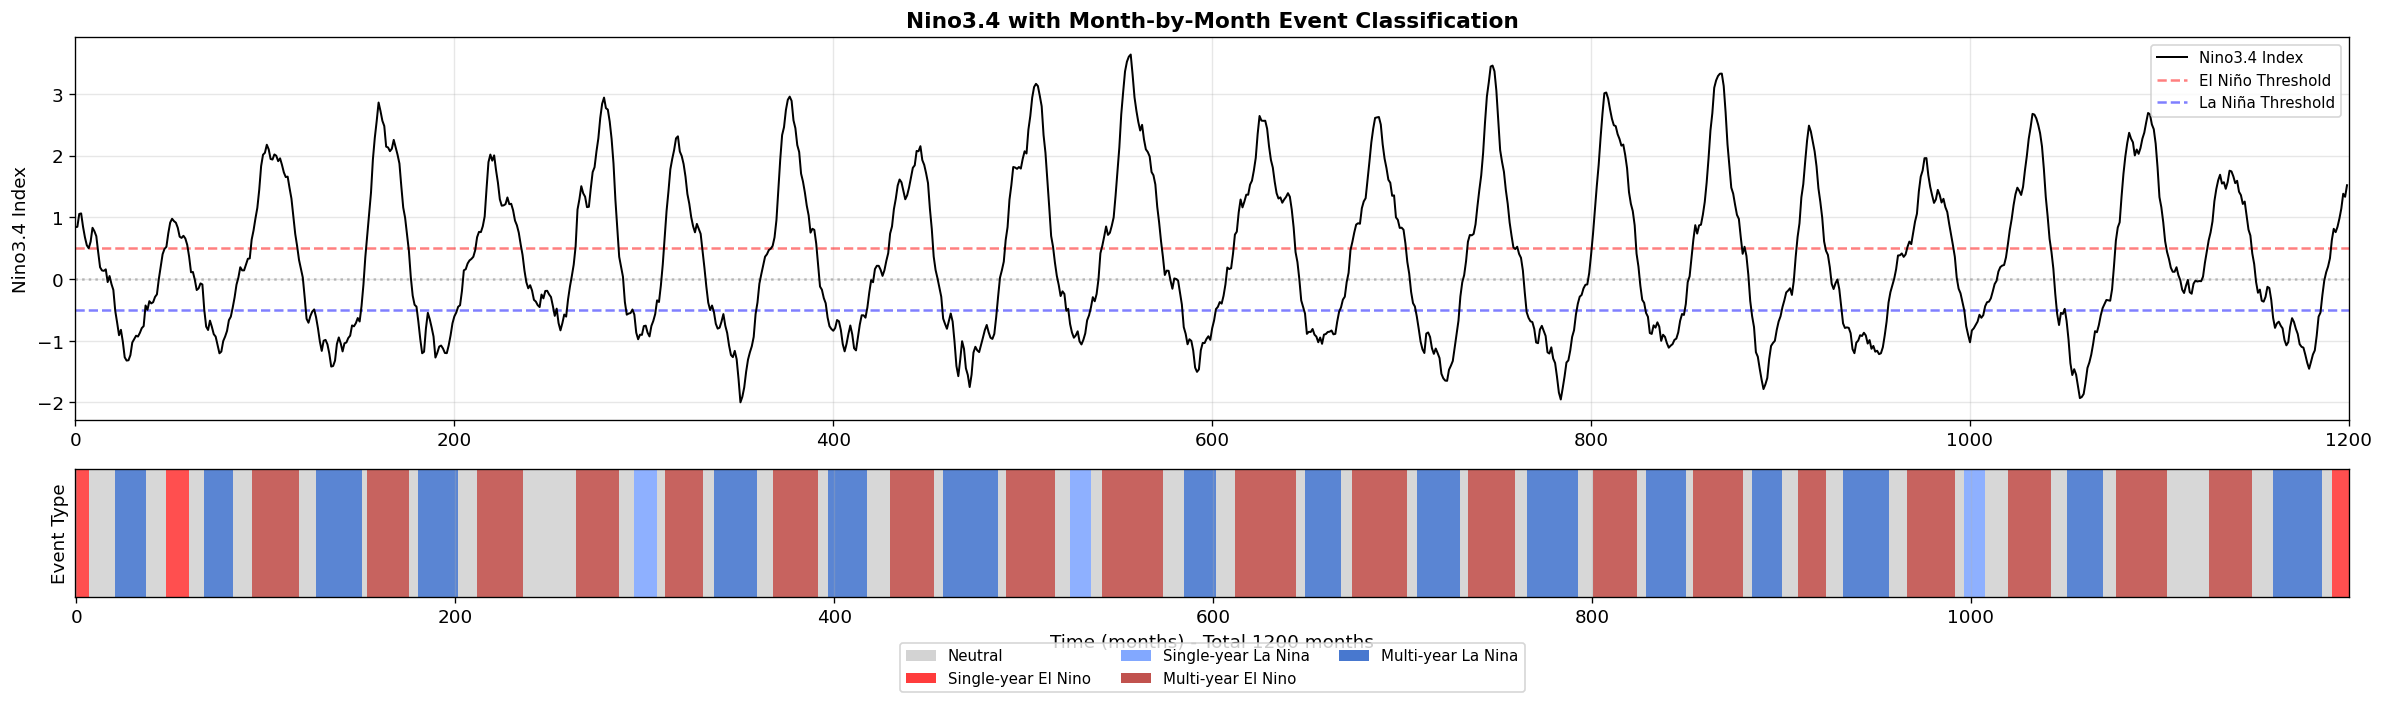

In [102]:
# Plot in paper
from matplotlib.patches import Patch

phase_color_map = {
    0: '#D3D3D3',  # Neutral
    1: '#FF3C3C',  # Single-year El Nino
    2: '#82A8FF',  # Single-year La Nina
    3: PHASE_COLORS['el_nino'],  # Multi-year El Nino
    4: PHASE_COLORS['la_nina'],  # Multi-year La Nina
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 6), height_ratios=[3, 1])

ax1.plot(enso_traj, linewidth=1.2, label='Nino3.4 Index', color='black', zorder=3)
ax1.set_xlim(0, T_traj)
ax1.axhline(THRESHOLD,  color='r', linestyle='--', alpha=0.5, linewidth=1.5, label='El Niño Threshold')
ax1.axhline(-THRESHOLD, color='b', linestyle='--', alpha=0.5, linewidth=1.5, label='La Niña Threshold')
ax1.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax1.set_title("Nino3.4 with Month-by-Month Event Classification", fontsize=13, fontweight='bold')
ax1.set_ylabel("Nino3.4 Index")
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

bar_colors = [phase_color_map[int(l)] for l in labels_traj]
ax2.bar(range(T_traj), np.ones(T_traj), color=bar_colors, width=1, edgecolor='none', alpha=0.9)
ax2.set_xlim(-0.5, T_traj - 0.5)
ax2.set_ylim(0, 1)
ax2.set_xlabel(f"Time (months) - Total {T_traj} months")
ax2.set_yticks([])
ax2.set_ylabel("Event Type")
ax2.grid(True, alpha=0.3, axis='x')

legend_elements = [Patch(facecolor=phase_color_map[k], label=LABEL_NAMES[k]) for k in phase_color_map]
ax2.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, -0.3), frameon=True, fontsize=9)

fig.tight_layout()
plt.show()

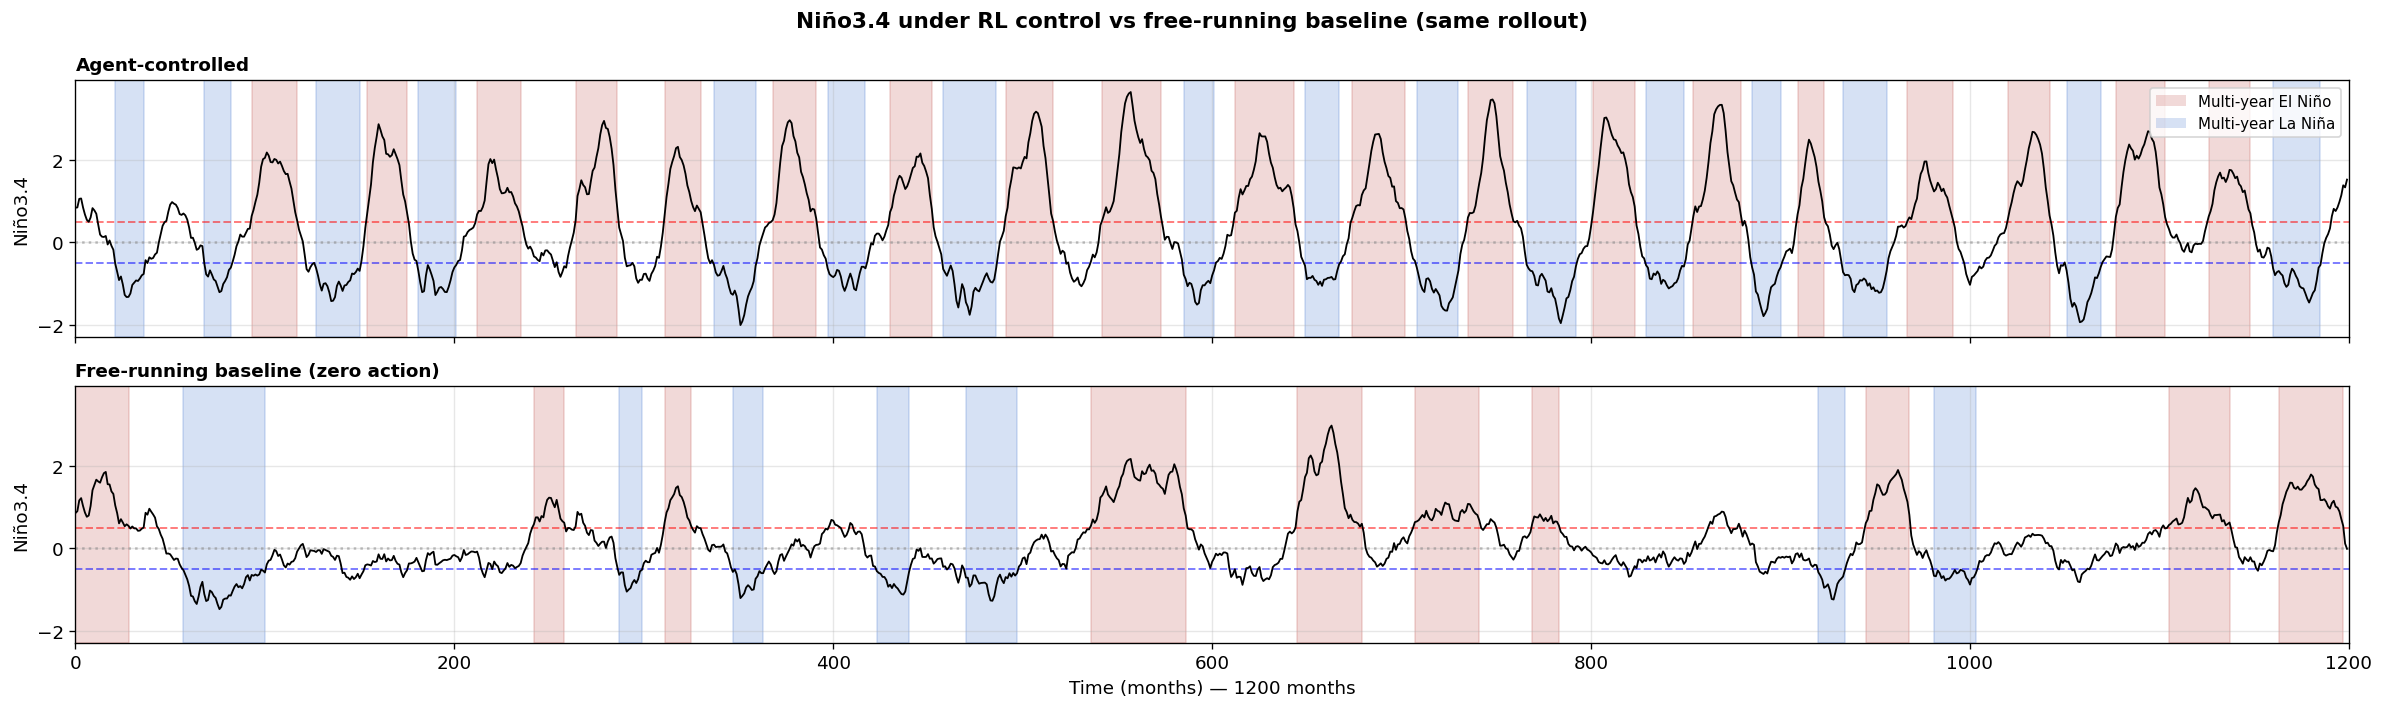

In [103]:
# Plot in paper
# --- 2.2.1b  Agent vs baseline Niño3.4 for the same representative rollout ---
# Same seed/rollout index; baseline is the zero-action XRO rollout. Shows the
# controller converting short, decaying events into sustained multi-year ones.
from matplotlib.patches import Patch
_MY = {3: PHASE_COLORS['el_nino'], 4: PHASE_COLORS['la_nina']}   # one palette, see nb_helper

enso_a = d_inf['agent_obs'][SEED_IDX, ROLLOUT_IDX, :, 0]
enso_b = d_inf['base_obs'][SEED_IDX, ROLLOUT_IDX, :, 0]
lab_a  = d_inf['agent_mye_label'][SEED_IDX, ROLLOUT_IDX]
lab_b  = d_inf['base_mye_label'][SEED_IDX, ROLLOUT_IDX]
Tt = len(enso_a)

fig, axes = plt.subplots(2, 1, figsize=(20, 6), sharex=True, sharey=True)
for ax, enso, lab, title in [
        (axes[0], enso_a, lab_a, 'Agent-controlled'),
        (axes[1], enso_b, lab_b, 'Free-running baseline (zero action)')]:
    ax.plot(enso, color='black', linewidth=1.1, zorder=3)
    ax.axhline(THRESHOLD,  color='r', ls='--', alpha=0.5, lw=1.2)
    ax.axhline(-THRESHOLD, color='b', ls='--', alpha=0.5, lw=1.2)
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    for ph, col in _MY.items():
        for s, e, _ in _find_continuous_runs((lab == ph).astype(int)):
            ax.axvspan(s, e, color=col, alpha=0.22)
    ax.set_ylabel('Niño3.4')
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.grid(alpha=0.3)
axes[0].set_xlim(0, Tt)
axes[1].set_xlabel(f'Time (months) — {Tt} months')
axes[0].legend(handles=[Patch(facecolor=_MY[3], alpha=0.22, label='Multi-year El Niño'),
                        Patch(facecolor=_MY[4], alpha=0.22, label='Multi-year La Niña')],
               loc='upper right', fontsize=9)
fig.suptitle('Niño3.4 under RL control vs free-running baseline (same rollout)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
save_fig(fig, BASE / '01b_traj_agent_vs_baseline.png')
save_fig(fig, FIGS / 'nino_rl_vs_base.png')
plt.show()

In [104]:
from utils.enso_table import create_enso_table, style_enso_table, save_enso_table_html
from IPython.display import display, HTML

# Calendar-aligned: columns are fixed DJF..NDJ; cells before/after the rollout
# (and any partial first/last year) are left blank.
df_enso = create_enso_table(enso_traj, threshold=THRESHOLD, start_month=start_month_sel)
styler  = style_enso_table(df_enso, threshold=THRESHOLD)

# Save interactive HTML alongside the other rng-action plots
out_html = BASE / "enso_table.html"
save_enso_table_html(enso_traj, output_path=str(out_html), threshold=THRESHOLD,
                     start_month=start_month_sel)
print(f"Saved -> {out_html.resolve()}")

# Render inline (red = El Niño, blue = La Niña, peaks bolded)
display(HTML(styler.to_html()))

Saved -> /Users/ayman/research/enso-rl/plots/model_postclip_quick/enso_table.html


,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
Year,,,,,,,,,,,,
1,,,,,,,,0.84,0.85,1.05,1.06,0.85
2,0.68,0.55,0.50,0.60,0.83,0.77,0.69,0.43,0.19,0.14,0.13,0.16
3,-0.05,0.05,-0.08,-0.18,-0.52,-0.71,-0.91,-0.82,-1.02,-1.27,-1.32,-1.32
4,-1.23,-1.03,-0.97,-0.92,-0.93,-0.87,-0.80,-0.76,-0.43,-0.50,-0.36,-0.40
5,-0.38,-0.29,-0.25,-0.00,0.20,0.40,0.49,0.52,0.74,0.91,0.98,0.94
6,0.91,0.83,0.69,0.67,0.70,0.66,0.55,0.36,0.11,0.11,-0.01,-0.18
7,-0.15,-0.07,-0.09,-0.50,-0.77,-0.83,-0.67,-0.78,-0.89,-0.93,-1.07,-1.20
8,-1.18,-1.01,-0.93,-0.84,-0.67,-0.61,-0.46,-0.30,-0.09,0.02,0.19,0.14
9,0.14,0.24,0.33,0.33,0.64,0.79,0.98,1.15,1.44,1.83,2.01,2.05


In [105]:
# Load raw inference data (replaces old lift_ensemble.npz + CSVs)
d_inf = load_inference(BASE / "inference.npz")
agent_label   = d_inf['agent_mye_label']   # [n_seeds, n_rollouts, T]
base_label    = d_inf['base_mye_label']
inf_var_names = list(d_inf['var_names'])
n_seeds_inf, n_rollouts_inf, T_inf = agent_label.shape

# --- Lift per phase: fraction of steps in each MYE category ---
lift_per_rollout = {}
per_seed_lift    = {}
agent_frac_all   = {}
base_frac_all    = {}

for phase, fn in PHASE_MASKS.items():
    a_frac = fn(agent_label).mean(axis=-1)   # [n_seeds, n_rollouts]
    b_frac = fn(base_label).mean(axis=-1)
    agent_frac_all[phase]   = a_frac
    base_frac_all[phase]    = b_frac
    lift_per_rollout[phase] = a_frac - b_frac
    per_seed_lift[phase]    = lift_per_rollout[phase].mean(axis=1)  # [n_seeds]

# CI and p-value across seeds (each seed = mean of its rollouts)
lift_summary = {}
for phase in PHASES:
    arr = per_seed_lift[phase]
    _, pval = ttest_1samp(arr, 0.0)
    lift_summary[phase] = dict(
        lift=arr.mean(),
        ci95=t_dist.ppf(0.975, df=len(arr)-1) * arr.std(ddof=1) / np.sqrt(len(arr)),
        pval=pval,
    )

print(f"Loaded: {n_seeds_inf} seeds × {n_rollouts_inf} rollouts × {T_inf} months")
for phase in PHASES:
    s = lift_summary[phase]
    print(f"  {phase:<8}  lift={s['lift']:+.4f}  CI95=±{s['ci95']:.4f}  "
          f"p={s['pval']:.4f}  {_sig_stars(s['pval'])}")

Loaded: 1 seeds × 15 rollouts × 1200 months
  total     lift=+0.3679  CI95=±nan  p=nan  ns
  el_nino   lift=+0.2427  CI95=±nan  p=nan  ns
  la_nina   lift=+0.1252  CI95=±nan  p=nan  ns


/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


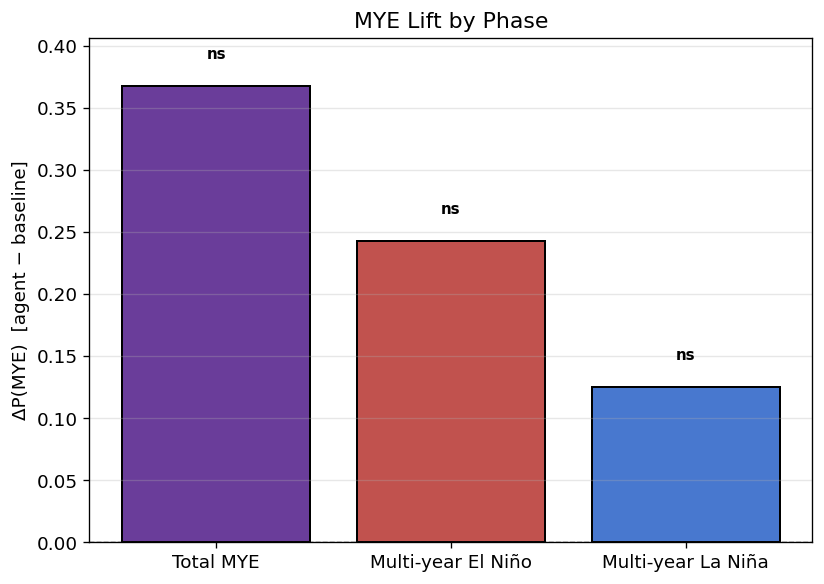

In [106]:
# --- 2a. Lift bar chart per phase ---
fig, ax = plt.subplots(figsize=(7, 5))
x      = np.arange(len(PHASES))
labels = [PHASE_LABELS[p] for p in PHASES]
lifts  = np.array([lift_summary[p]['lift']  for p in PHASES])
ci95   = np.array([lift_summary[p]['ci95']  for p in PHASES])
pvals  = np.array([lift_summary[p]['pval']  for p in PHASES])
colors = [PHASE_COLORS[p] for p in PHASES]

ax.bar(x, lifts, color=colors, edgecolor="black", linewidth=1.2,
       yerr=ci95, capsize=6, error_kw={"linewidth": 1.5})
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
_add_sig_labels(ax, x, lifts, pvals)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("ΔP(MYE)  [agent − baseline]")
ax.set_title("MYE Lift by Phase")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

In [107]:
# per_seed_lift computed in Section 2 (Lift Analysis) from inference.npz
lift_en = per_seed_lift['el_nino']   # [n_seeds]
lift_ln = per_seed_lift['la_nina']   # [n_seeds]
n_seeds = len(lift_en)
print(f"Seeds: {n_seeds}  |  El Niño lift: {lift_en.mean():.3f} ± {lift_en.std():.3f}")
print(f"                    La Niña lift: {lift_ln.mean():.3f} ± {lift_ln.std():.3f}")

Seeds: 1  |  El Niño lift: 0.243 ± 0.000
                    La Niña lift: 0.125 ± 0.000


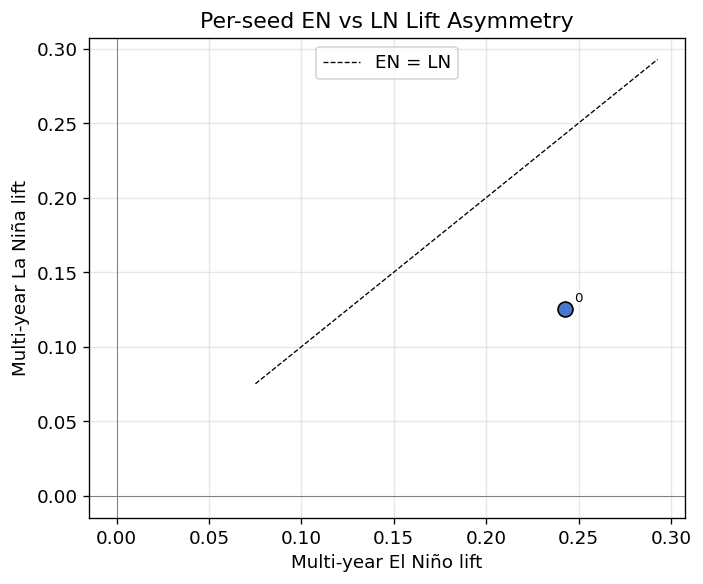

In [108]:
# --- 3a. EN vs LN lift scatter per seed ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(lift_en, lift_ln, s=80, color="#4878CF", edgecolor="black", zorder=3)
for i, (x_, y_) in enumerate(zip(lift_en, lift_ln)):
    ax.text(x_ + 0.005, y_ + 0.005, str(i), fontsize=8)
lims = [min(lift_en.min(), lift_ln.min()) - 0.05,
        max(lift_en.max(), lift_ln.max()) + 0.05]
ax.plot(lims, lims, "k--", linewidth=0.8, label="EN = LN")
ax.axhline(0, color="grey", linewidth=0.6); ax.axvline(0, color="grey", linewidth=0.6)
ax.set_xlabel("Multi-year El Niño lift"); ax.set_ylabel("Multi-year La Niña lift")
ax.set_title("Per-seed EN vs LN Lift Asymmetry")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 2.2.2 Event statistics — more frequent, or longer-lived?

Decomposes the lift into **event count** and **event duration** (not just months in
an MYE), then shows the **duration survival curve** S(t) = P(event lasts ≥ t
months). The key result: the lift is **frequency-driven** — the agent makes far more
multi-year events, of comparable individual length. The scalar event statistics
(including the single-year → multi-year conversion rate, ~ the conventional ONI
≥5-overlapping-season event definition) are consolidated in **Table 1 (§2.2.3)**.

/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


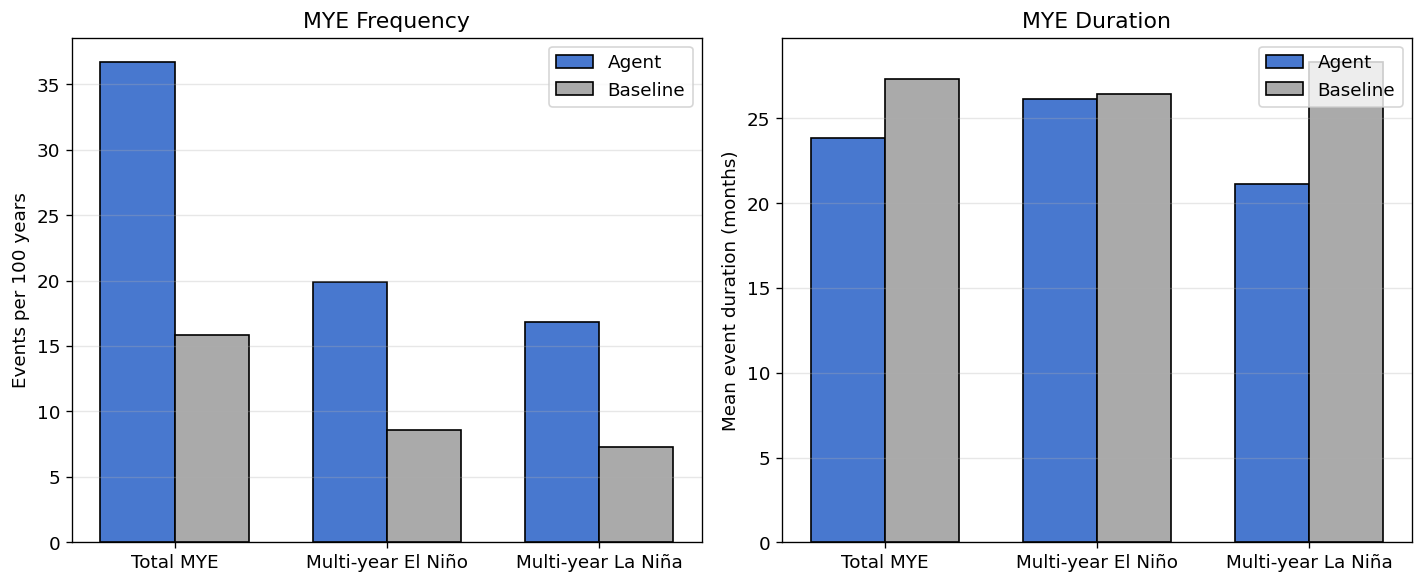

In [109]:
# Plot in paper
# --- 2b. Frequency & duration decomposition ---
# Count events and measure durations from raw labels via _find_continuous_runs
years_per_rollout = T_inf / 12
century_scale     = 100.0 / years_per_rollout

freq_agent = {p: np.zeros(n_seeds_inf) for p in PHASES}
freq_base  = {p: np.zeros(n_seeds_inf) for p in PHASES}
dur_agent  = {p: np.zeros(n_seeds_inf) for p in PHASES}
dur_base   = {p: np.zeros(n_seeds_inf) for p in PHASES}

for si in range(n_seeds_inf):
    for phase, fn in PHASE_MASKS.items():
        cnts_a, durs_a, cnts_b, durs_b = [], [], [], []
        for ri in range(n_rollouts_inf):
            runs_a = _find_continuous_runs(fn(agent_label[si, ri]).astype(int))
            cnts_a.append(len(runs_a))
            durs_a.extend([r[2] for r in runs_a])
            runs_b = _find_continuous_runs(fn(base_label[si, ri]).astype(int))
            cnts_b.append(len(runs_b))
            durs_b.extend([r[2] for r in runs_b])
        freq_agent[phase][si] = np.mean(cnts_a) * century_scale
        freq_base[phase][si]  = np.mean(cnts_b) * century_scale
        dur_agent[phase][si]  = np.mean(durs_a) if durs_a else 0.0
        dur_base[phase][si]   = np.mean(durs_b) if durs_b else 0.0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x      = np.arange(len(PHASES))
labels = [PHASE_LABELS[p] for p in PHASES]
w      = 0.35

ax = axes[0]
for i, phase in enumerate(PHASES):
    mA, cA = _mean_ci(freq_agent[phase])
    mB, cB = _mean_ci(freq_base[phase])
    ax.bar(i - w/2, mA, w, label="Agent"    if i == 0 else "", color="#4878CF",
           yerr=cA, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
    ax.bar(i + w/2, mB, w, label="Baseline" if i == 0 else "", color="#aaaaaa",
           yerr=cB, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Events per 100 years")
ax.set_title("MYE Frequency")
ax.legend(); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
for i, phase in enumerate(PHASES):
    mA, cA = _mean_ci(dur_agent[phase])
    mB, cB = _mean_ci(dur_base[phase])
    ax.bar(i - w/2, mA, w, label="Agent"    if i == 0 else "", color="#4878CF",
           yerr=cA, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
    ax.bar(i + w/2, mB, w, label="Baseline" if i == 0 else "", color="#aaaaaa",
           yerr=cB, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Mean event duration (months)")
ax.set_title("MYE Duration")
ax.legend(); ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
save_fig(fig, FIGS / "lift.png")
plt.show()


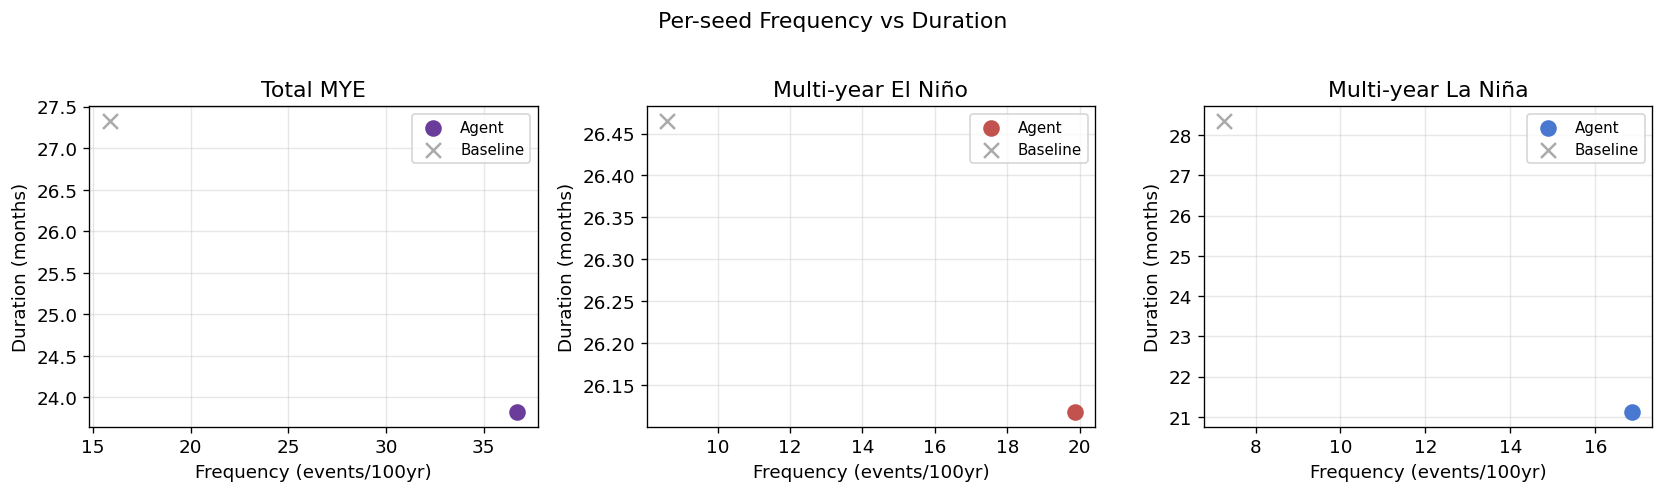

In [110]:
# --- 2c. Per-seed freq–duration scatter (robustness check) ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(14, 4), sharey=False)
for ax, phase in zip(axes, PHASES):
    ax.scatter(freq_agent[phase], dur_agent[phase],
               color=PHASE_COLORS[phase], s=80, zorder=3, label="Agent")
    ax.scatter(freq_base[phase], dur_base[phase],
               color="#aaaaaa", marker="x", s=80, zorder=3, label="Baseline")
    ax.set_xlabel("Frequency (events/100yr)")
    ax.set_ylabel("Duration (months)")
    ax.set_title(PHASE_LABELS[phase])
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.suptitle("Per-seed Frequency vs Duration", y=1.02)
fig.tight_layout()
plt.show()

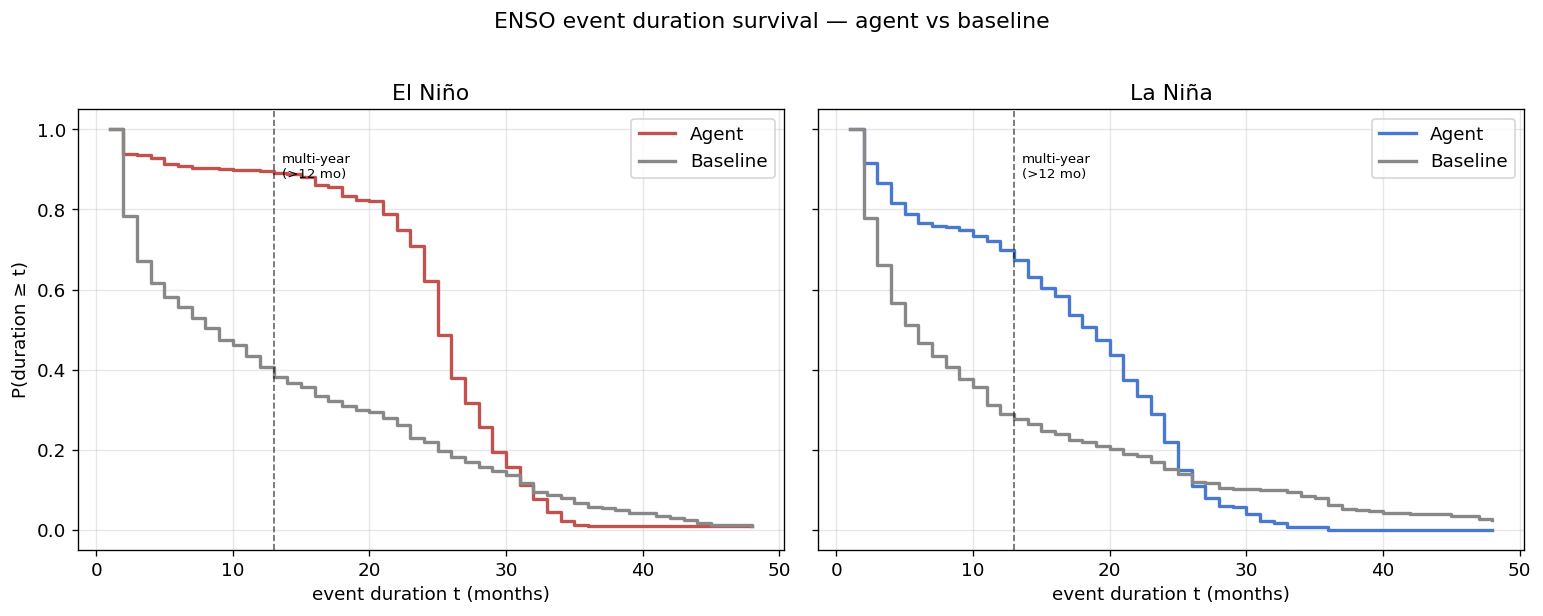

In [111]:
# --- 2.2.2d  Duration survival curve  S(t) = P(event lasts >= t months) ---
# Built from RAW threshold exceedances (any length) so the full duration
# distribution shows; dashed line = multi-year band (>12 mo). The agent's curve
# has a much fatter tail past 13 months.
SP = int(d_inf['spinup'])
aobs, bobs = d_inf['agent_obs'], d_inf['base_obs']

def _durations(obs, sign):
    ns_, nr_, Ts = obs.shape[:3]
    durs = []
    for si in range(ns_):
        for ri in range(nr_):
            nino = obs[si, ri, :, 0]
            cond = (nino >= THRESHOLD) if sign > 0 else (nino <= -THRESHOLD)
            for s, e, L in _find_continuous_runs(cond.astype(int)):
                if s < SP or e >= Ts - 1:
                    continue
                durs.append(L)
    return np.asarray(durs)

ts = np.arange(1, 49)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (ph, sign, lbl) in zip(axes,
        [('el_nino', +1, 'El Niño'), ('la_nina', -1, 'La Niña')]):
    for obs, color, name in [(aobs, PHASE_COLORS[ph], 'Agent'),
                             (bobs, '#888888', 'Baseline')]:
        durs = _durations(obs, sign)
        surv = np.array([(durs >= t).mean() for t in ts])
        ax.step(ts, surv, where='post', color=color, linewidth=2, label=name)
    ax.axvline(13, color='k', ls='--', alpha=0.6, lw=1)
    ax.text(13.6, 0.88, 'multi-year\n(>12 mo)', fontsize=8)
    ax.set_xlabel('event duration t (months)'); ax.set_title(lbl)
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('P(duration ≥ t)')
fig.suptitle('ENSO event duration survival — agent vs baseline', y=1.02)
fig.tight_layout()
save_fig(fig, BASE / '02d_duration_survival.png')
plt.show()

## 2.2.3 Seasonal timing and amplitude of controlled events

When multi-year events onset, peak, and terminate over the seasonal cycle, and how
strong they are (peak |Niño3.4| per event) — agent vs baseline. **Table 1**
consolidates the §2.2 event statistics (frequency, duration, conversion, amplitude).

In [112]:
# --- 6. Per-event onset / termination / peak calendar month ---
# Reuses d_inf (inference.npz). Counts discrete EVENTS (continuous runs of an MYE
# label) and bins by TRUE calendar month (step + rollout_start_month) % 12.
SPINUP_ev = int(d_inf['spinup'])              # 12-month transient skipped
# reset() starts the seasonal clock at the sampled state's month, so bin by the
# TRUE calendar month. Older inference.npz lacks this -> fall back to a Jan start
# (re-run scripts/analysis/inference.py to get correct calendar binning).
if 'rollout_start_month' in d_inf.files:
    start_all = d_inf['rollout_start_month']  # [n_seeds, n_rollouts], 0=Jan
else:
    start_all = np.zeros(d_inf['agent_mye_label'].shape[:2], dtype=int)
    print('WARNING: rollout_start_month missing from inference.npz - binning by '
          'step%12 (assumes Jan start); re-run inference.py for true months.')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def event_month_counts(labels, obs, phase, sign):
    """Count multi-year events of `phase` (3=El Nino, 4=La Nina) by the calendar
    month of their onset, termination, and peak. `sign` is +1 (warmest month,
    El Nino) or -1 (coldest, La Nina).

    Each continuous run of the label is one event. Events starting inside the
    spinup transient or right-censored at the rollout end are dropped, so all
    three histograms share one event set.

    PEAK TIE HANDLING. Nino3.4 is hard-clipped to the observed record range by the
    environment (utils/physics.py), and under the agent ~75% of MY El Nino events
    reach that ceiling -- for a median of 4 consecutive months. np.argmax would
    return the FIRST of those tied months, i.e. the month the event hit the
    ceiling rather than its peak, biasing the El Nino peak-month distribution
    ~3 months early (mode Aug instead of Nov). We therefore take the MIDPOINT of
    the tied plateau. La Nina is largely unaffected (4.1% of events clipped, and never for a
    long plateau) and the baseline nearly so (2.6% / 0.5%), so this changes only
    the agent El Nino curve.

    Also returns the fraction of events whose peak sits exactly on the bound: for
    those events the peak AMPLITUDE is right-censored and is a lower bound, not a
    measurement.
    """
    starts = np.zeros(12, int); ends = np.zeros(12, int); peaks = np.zeros(12, int)
    n_clip = n_ev = 0
    bound = float(np.max(obs[:, :, :, 0]) if sign > 0 else np.min(obs[:, :, :, 0]))
    n_s, n_r, T = labels.shape
    for si in range(n_s):
        for ri in range(n_r):
            sm   = int(start_all[si, ri])
            seq  = (labels[si, ri] == phase).astype(int)
            nino = obs[si, ri, :, 0]
            for s, e, _ in _find_continuous_runs(seq):
                if s < SPINUP_ev or e >= T - 1:
                    continue
                seg  = nino[s:e + 1]
                ext  = seg.max() if sign > 0 else seg.min()
                tied = np.flatnonzero(np.abs(seg - ext) < 1e-6)   # plateau at the extreme
                pk   = s + int(tied[len(tied) // 2])              # midpoint of the plateau
                starts[(s  + sm) % 12] += 1
                ends  [(e  + sm) % 12] += 1
                peaks [(pk + sm) % 12] += 1
                n_ev   += 1
                n_clip += abs(float(ext) - bound) < 1e-3
    return starts, ends, peaks, n_clip / max(n_ev, 1)

agent_en = event_month_counts(d_inf['agent_mye_label'], d_inf['agent_obs'], 3, +1)
agent_ln = event_month_counts(d_inf['agent_mye_label'], d_inf['agent_obs'], 4, -1)
base_en  = event_month_counts(d_inf['base_mye_label'],  d_inf['base_obs'],  3, +1)
base_ln  = event_month_counts(d_inf['base_mye_label'],  d_inf['base_obs'],  4, -1)

print("Multi-year events counted (agent / baseline):")
print(f"  El Nino : {agent_en[0].sum():4d} / {base_en[0].sum():4d}")
print(f"  La Nina : {agent_ln[0].sum():4d} / {base_ln[0].sum():4d}")
print("\nPeak sits exactly on the environment's clip (amplitude right-censored):")
print(f"  El Nino : agent {agent_en[3]:5.1%} / baseline {base_en[3]:5.1%}")
print(f"  La Nina : agent {agent_ln[3]:5.1%} / baseline {base_ln[3]:5.1%}")


Multi-year events counted (agent / baseline):
  El Nino :  290 /  122
  La Nina :  249 /  106

Peak sits exactly on the environment's clip (amplitude right-censored):
  El Nino : agent  0.7% / baseline  0.0%
  La Nina : agent  0.4% / baseline  0.9%


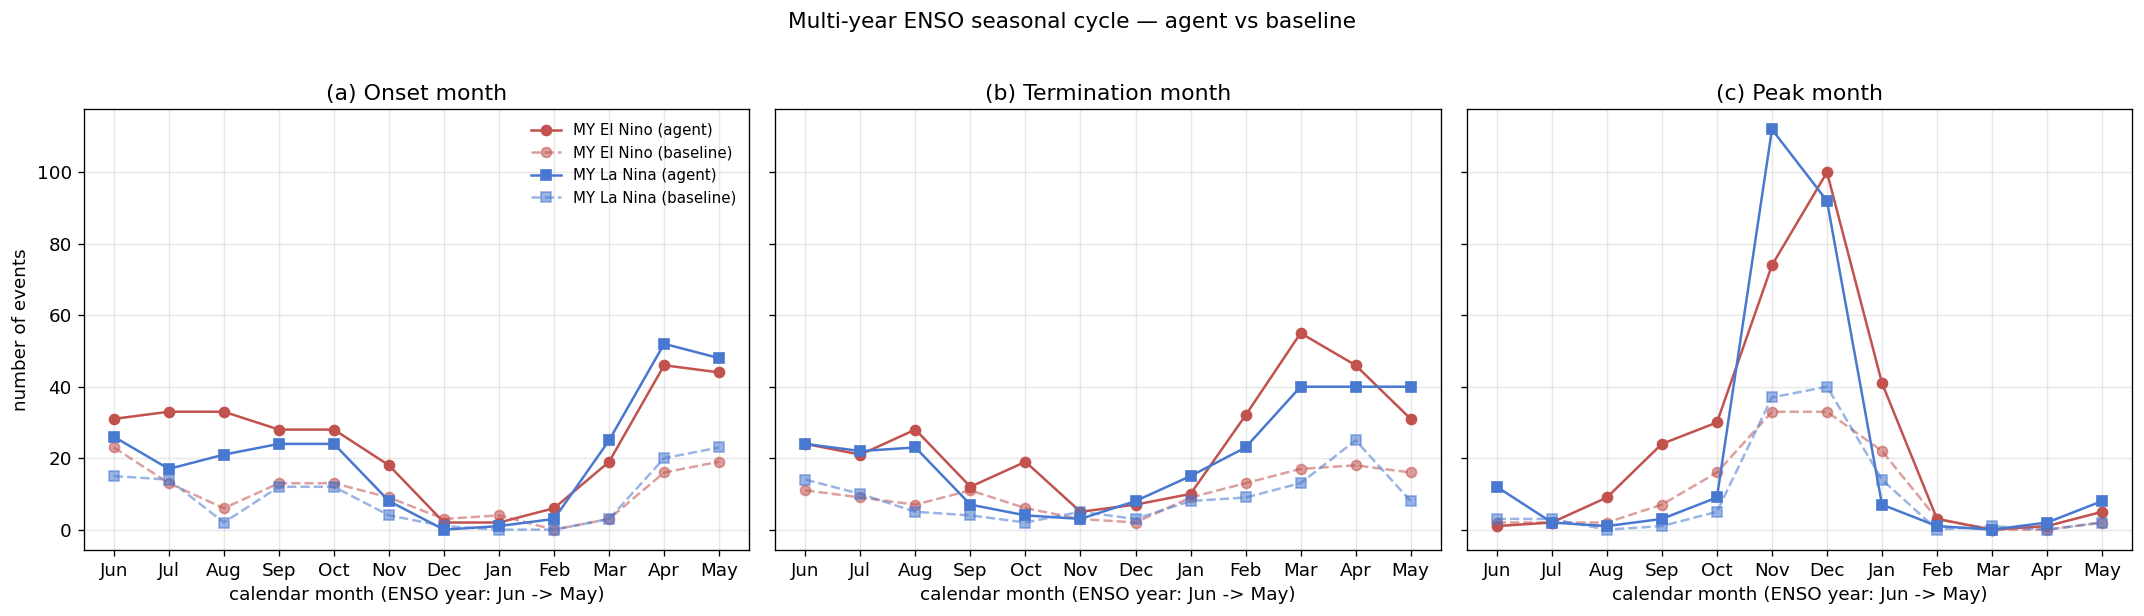

In [113]:
# Plot in paper
# --- 6a-c. Onset / termination / peak month, ENSO year (Jun -> May) ---
# 4 lines: El Nino (red) / La Nina (blue) x agent (solid) / baseline (dashed).
ORDER = [5, 6, 7, 8, 9, 10, 11, 0, 1, 2, 3, 4]        # Jun .. May
xlab  = [month_names[m] for m in ORDER]
EN_C, LN_C = PHASE_COLORS['el_nino'], PHASE_COLORS['la_nina']   # one palette, see nb_helper

def _draw_seasonal(ax, i, title, legend=True):         # i: 0=onset, 1=end, 2=peak
    ax.plot(range(12), agent_en[i][ORDER], '-o',  color=EN_C, label='MY El Nino (agent)')
    ax.plot(range(12), base_en[i][ORDER],  '--o', color=EN_C, alpha=0.55, label='MY El Nino (baseline)')
    ax.plot(range(12), agent_ln[i][ORDER], '-s',  color=LN_C, label='MY La Nina (agent)')
    ax.plot(range(12), base_ln[i][ORDER],  '--s', color=LN_C, alpha=0.55, label='MY La Nina (baseline)')
    ax.set_xticks(range(12)); ax.set_xticklabels(xlab)
    ax.set_xlabel('calendar month (ENSO year: Jun -> May)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if legend:
        ax.legend(frameon=False, fontsize=9)

# --- combined: all three side by side (1 row x 3 columns), shared y-axis ---
PANELS = [(0, '(a) Onset month'), (1, '(b) Termination month'), (2, '(c) Peak month')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (i, title) in zip(axes, PANELS):
    _draw_seasonal(ax, i, title, legend=(i == 0))
axes[0].set_ylabel('number of events')
fig.suptitle('Multi-year ENSO seasonal cycle — agent vs baseline', y=1.02, fontsize=13)
fig.tight_layout()
save_fig(fig, FIGS / 'mye_seasonal_cycle.png')
plt.show()


In [114]:
# Plot in paper
# --- Table 1  Multi-year ENSO event characteristics (agent vs baseline) ---
# Consolidates the near-scalar event statistics — frequency, duration, conversion,
# amplitude — into one table, per phase, with 95% CIs across seeds. Conversion is
# reported here (not as a bar) because the agent saturates near 100%; the survival
# curve (2.2.2) is its distributional view. NOTE the duration column: the lift is
# frequency-driven (agent makes ~2.6x MORE events), not longer individual events.
import pandas as pd
SP = int(d_inf['spinup'])
T_tab = d_inf['agent_obs'].shape[2]
century = 100.0 / (T_tab / 12)

def _event_metrics(lab, obs, phase):
    sy = 1 if phase == 3 else 2                     # single-year label for this phase
    ns_, nr_ = lab.shape[:2]
    freq = np.zeros(ns_); dur = np.zeros(ns_)
    conv = np.full(ns_, np.nan); amp = np.full(ns_, np.nan)
    for si in range(ns_):
        cnt, durs, amps, ev, mult = 0, [], [], 0, 0
        for ri in range(nr_):
            seq = lab[si, ri]; nino = obs[si, ri, :, 0]
            for s, e, L in _find_continuous_runs((seq == phase).astype(int)):
                if s < SP or e >= T_tab - 1:
                    continue
                cnt += 1; durs.append(L)
                seg = nino[s:e + 1]
                amps.append(seg.max() if phase == 3 else -seg.min())
            for s, e, _ in _find_continuous_runs(((seq == sy) | (seq == phase)).astype(int)):
                if s < SP or e >= T_tab - 1:
                    continue
                ev += 1
                if (seq[s:e + 1] == phase).any():
                    mult += 1
        freq[si] = cnt / nr_ * century
        dur[si]  = np.mean(durs) if durs else 0.0
        amp[si]  = np.mean(amps) if amps else np.nan
        conv[si] = mult / ev if ev else np.nan
    return dict(freq=freq, dur=dur, conv=conv, amp=amp)

def _pm(a):
    v = a[~np.isnan(a)]; m, c = _mean_ci(v); return f"{m:.2f} ± {c:.2f}"

rows = []
for phase, plabel in [(3, 'Multi-year El Niño'), (4, 'Multi-year La Niña')]:
    A = _event_metrics(d_inf['agent_mye_label'], d_inf['agent_obs'], phase)
    B = _event_metrics(d_inf['base_mye_label'],  d_inf['base_obs'],  phase)
    for run, M in [('Agent', A), ('Baseline', B)]:
        rows.append([plabel, run, _pm(M['freq']), _pm(M['dur']),
                     f"{100 * np.nanmean(M['conv']):.1f}", _pm(M['amp'])])

tbl = pd.DataFrame(rows, columns=['Phase', 'Run', 'Events / 100 yr',
        'Mean duration (mo)', 'Conversion (%)', 'Peak |Niño3.4| (σ)'])
print(tbl.to_string(index=False))
try:
    from IPython.display import display
    display(tbl.style.hide(axis='index').set_caption(
        'Table 1 — Multi-year ENSO event characteristics '
        '(agent vs baseline; ±95% CI across seeds)'))
except Exception:
    pass

             Phase      Run Events / 100 yr Mean duration (mo) Conversion (%) Peak |Niño3.4| (σ)
Multi-year El Niño    Agent     19.33 ± nan        26.21 ± nan           98.3         3.04 ± nan
Multi-year El Niño Baseline      8.13 ± nan        26.48 ± nan           68.5         1.71 ± nan
Multi-year La Niña    Agent     16.60 ± nan        21.20 ± nan           88.0         1.52 ± nan
Multi-year La Niña Baseline      7.07 ± nan        28.49 ± nan           59.2         1.26 ± nan


/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/ayman/research/enso-rl/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Phase,Run,Events / 100 yr,Mean duration (mo),Conversion (%),Peak |Niño3.4| (σ)
Multi-year El Niño,Agent,19.33 ± nan,26.21 ± nan,98.3,3.04 ± nan
Multi-year El Niño,Baseline,8.13 ± nan,26.48 ± nan,68.5,1.71 ± nan
Multi-year La Niña,Agent,16.60 ± nan,21.20 ± nan,88.0,1.52 ± nan
Multi-year La Niña,Baseline,7.07 ± nan,28.49 ± nan,59.2,1.26 ± nan


## 2.2.4 What the controller does to the climate modes (descriptive)

The state-space signature (how the agent reshapes each mode's distribution), an
**in-distribution / realism check** (states stay inside the observed multivariate
envelope), the magnitude and sign of the agent's forcing per mode and by event
phase, and the seasonality of control. These describe *what* the policy does; §2.3
asks *which* of these actions causally sustain events.

In [115]:
from scipy.stats import gaussian_kde

agent_obs = d_inf['agent_obs']   # [n_seeds, n_rollouts, T, 10]
base_obs  = d_inf['base_obs']    # [n_seeds, n_rollouts, T, 10]
kde_vars  = list(d_inf['var_names'])   # ['Nino3.4', 'WWV', ...]
n_vars    = agent_obs.shape[-1]

# Flatten over seeds × rollouts × time for KDE
agent_flat = agent_obs.reshape(-1, n_vars)   # [N, 10]
base_flat  = base_obs.reshape(-1, n_vars)

print(f"KDE samples per variable: {agent_flat.shape[0]:,}  (agent)  "
      f"{base_flat.shape[0]:,}  (baseline)")
print(f"Variables: {kde_vars}")

KDE samples per variable: 18,000  (agent)  18,000  (baseline)
Variables: [np.str_('Nino34'), np.str_('WWV'), np.str_('NPMM'), np.str_('SPMM'), np.str_('IOB'), np.str_('IOD'), np.str_('SIOD'), np.str_('TNA'), np.str_('ATL3'), np.str_('SASD')]


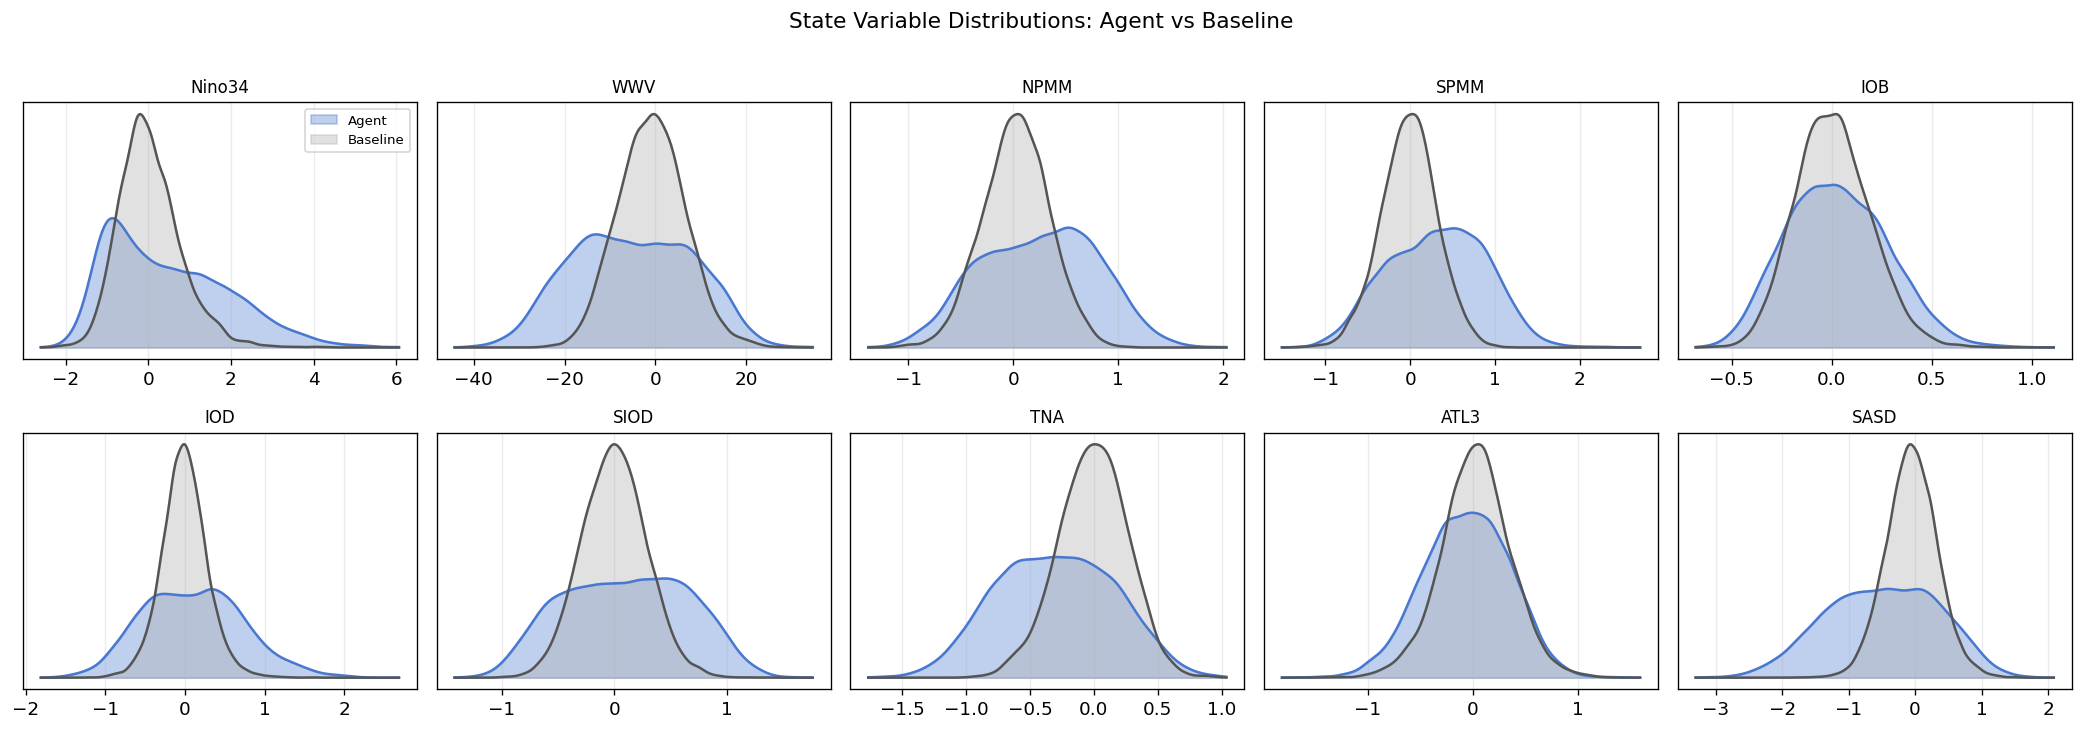

In [116]:
# Plot in paper
# --- 5. KDE grid: agent vs baseline for each state variable ---
# Subsample for speed (KDE on 360 k points is slow)
rng_kde = np.random.default_rng(0)
max_pts = 50_000
idx_a   = rng_kde.choice(agent_flat.shape[0], min(max_pts, agent_flat.shape[0]), replace=False)
idx_b   = rng_kde.choice(base_flat.shape[0],  min(max_pts, base_flat.shape[0]),  replace=False)

ncols = 5
nrows = int(np.ceil(n_vars / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
axes_flat = axes.ravel()

for vi, vname in enumerate(kde_vars):
    ax = axes_flat[vi]
    a_vals = agent_flat[idx_a, vi]
    b_vals = base_flat[idx_b, vi]

    lo = min(a_vals.min(), b_vals.min())
    hi = max(a_vals.max(), b_vals.max())
    xs = np.linspace(lo, hi, 300)

    kde_a = gaussian_kde(a_vals, bw_method=0.15)
    kde_b = gaussian_kde(b_vals, bw_method=0.15)

    ax.fill_between(xs, kde_a(xs), alpha=0.35, color="#4878CF", label="Agent")
    ax.fill_between(xs, kde_b(xs), alpha=0.35, color="#aaaaaa", label="Baseline")
    ax.plot(xs, kde_a(xs), color="#4878CF", linewidth=1.5)
    ax.plot(xs, kde_b(xs), color="#555555", linewidth=1.5)
    ax.set_title(vname, fontsize=10)
    ax.set_yticks([])
    ax.grid(alpha=0.25)

# Hide unused axes
for ax in axes_flat[n_vars:]:
    ax.set_visible(False)

axes_flat[0].legend(fontsize=8, loc="upper right")
fig.suptitle("State Variable Distributions: Agent vs Baseline", fontsize=13, y=1.01)
fig.tight_layout()
save_fig(fig, FIGS / "state_variables.png")
plt.show()


Observed envelope threshold d²_max = 33.2
Agent    states inside envelope: 90.1%
Baseline states inside envelope: 100.0%


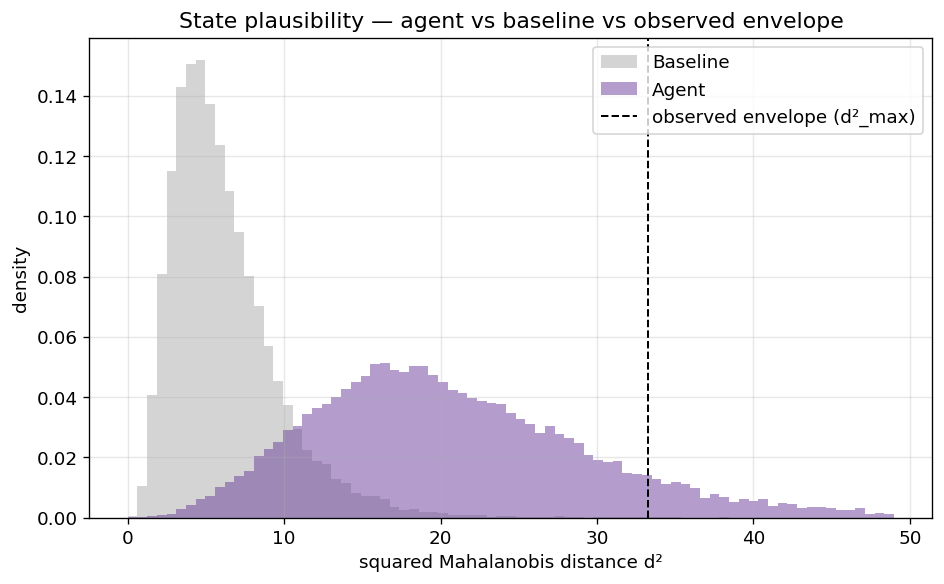

In [117]:
# --- 2.2.4c  In-distribution / realism check (Mahalanobis) ---
# Replicates the env's realism reference (envs/xro_env.py _init_realism_reference):
# observed-climatology mean + inverse covariance, activation threshold = max squared
# Mahalanobis distance over observed states. Fraction of agent states inside this
# observed envelope rebuts "the agent exploits unphysical states".
import xarray as xr
from config import EnvConfig

_dc  = EnvConfig().data_config
_rep = Path('..').resolve()
_obs = xr.open_dataset(_rep / _dc['data_path']).sel(
    time=slice(_dc['train_start'], _dc['train_end']))
_vn  = list(d_inf['var_names'])
_os  = np.column_stack([np.asarray(_obs[n].values, float) for n in _vn])
_os  = _os[~np.isnan(_os).any(axis=1)]

_mu   = _os.mean(0)
_icov = np.linalg.inv(np.cov(_os, rowvar=False) + np.eye(len(_vn)) * 1e-6)
_thr  = float(np.einsum('ni,ij,nj->n', _os - _mu, _icov, _os - _mu).max())

def _d2(obs):
    flat = obs.reshape(-1, obs.shape[-1])
    return np.einsum('ni,ij,nj->n', flat - _mu, _icov, flat - _mu)

d2a, d2b = _d2(d_inf['agent_obs']), _d2(d_inf['base_obs'])
print(f"Observed envelope threshold d²_max = {_thr:.1f}")
print(f"Agent    states inside envelope: {(d2a <= _thr).mean()*100:.1f}%")
print(f"Baseline states inside envelope: {(d2b <= _thr).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, np.percentile(np.concatenate([d2a, d2b]), 99.5), 80)
ax.hist(d2b, bins=bins, density=True, alpha=0.5, color='#aaaaaa', label='Baseline')
ax.hist(d2a, bins=bins, density=True, alpha=0.5, color=PHASE_COLORS['total'], label='Agent')
ax.axvline(_thr, color='k', ls='--', lw=1.2, label='observed envelope (d²_max)')
ax.set_xlabel('squared Mahalanobis distance d²'); ax.set_ylabel('density')
ax.set_title('State plausibility — agent vs baseline vs observed envelope')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, BASE / '05c_realism_check.png')
plt.show()

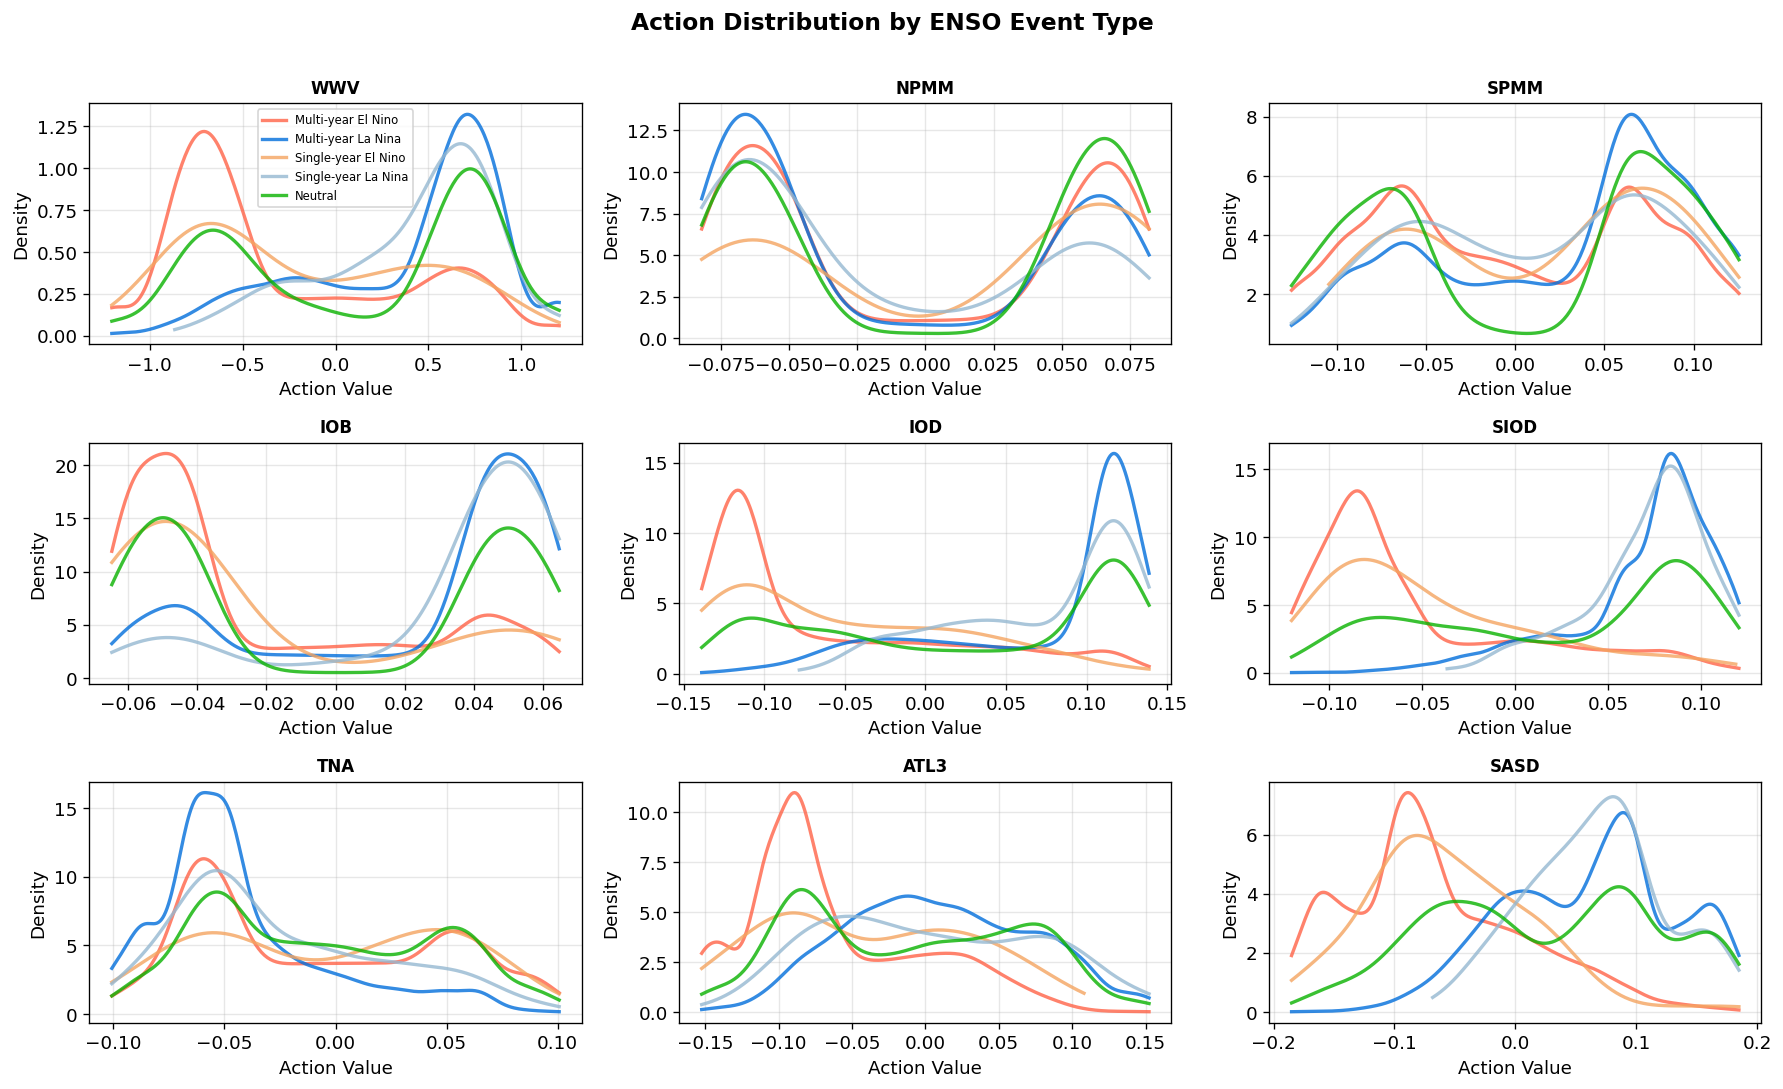

In [118]:
# Plot in paper
# Aggregated over ALL seeds x rollouts (not just the representative one) so each
# phase KDE has enough samples to be stable.
from scipy.stats import gaussian_kde

EVENT_ORDER      = [3, 4, 1, 2, 0]  # Multi-EN, Multi-LN, Single-EN, Single-LN, Neutral
kde_event_colors = {3: '#FF6347', 4: "#016EDB", 1: '#F4A460', 2: '#95B8D1', 0: "#09B200"}

all_labels = d_inf['agent_mye_label'].reshape(-1)   # [N]

def _kde_grid_by_event(data, names, title, xlabel, ncols=3, max_pts=20_000, save_as=None):
    """KDE of each column in `data`, one curve per ENSO phase, on a subplot grid."""
    rng = np.random.default_rng(0)
    n   = len(names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3))
    axes_flat = np.atleast_1d(axes).ravel()

    for i, name in enumerate(names):
        ax  = axes_flat[i]
        col = data[:, i]
        for ev in EVENT_ORDER:
            vals = col[all_labels == ev]
            if len(vals) < 10 or vals.std() < 1e-9:
                continue
            if len(vals) > max_pts:
                vals = vals[rng.choice(len(vals), max_pts, replace=False)]
            xs = np.linspace(vals.min(), vals.max(), 300)
            ax.plot(xs, gaussian_kde(vals)(xs), color=kde_event_colors[ev],
                    linewidth=2, alpha=0.8, label=LABEL_NAMES[ev])
        ax.set_title(name, fontsize=10, fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)

    for ax in axes_flat[n:]:
        ax.set_visible(False)
    axes_flat[0].legend(fontsize=7, loc='best')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.005)
    fig.tight_layout()
    if save_as:
        save_fig(fig, FIGS / save_as)
    plt.show()

# RAW actions, not physical forcing: pooling 1200 months of scaled forcing mixes 12
# different monthly scales into one density, which is exactly what a KDE is worst at.
# Raw also puts the saturation spikes at +/-1 and matches the per-mode KDE below.
all_actions = d_inf['agent_actions_raw'].reshape(-1, len(traj_action_names))
_kde_grid_by_event(all_actions, traj_action_names,
                   "Raw Action Distribution by ENSO Event Type",
                   "Raw action  ($\\pm$1 = actuation bound)",
                   save_as="action_event_type.png")

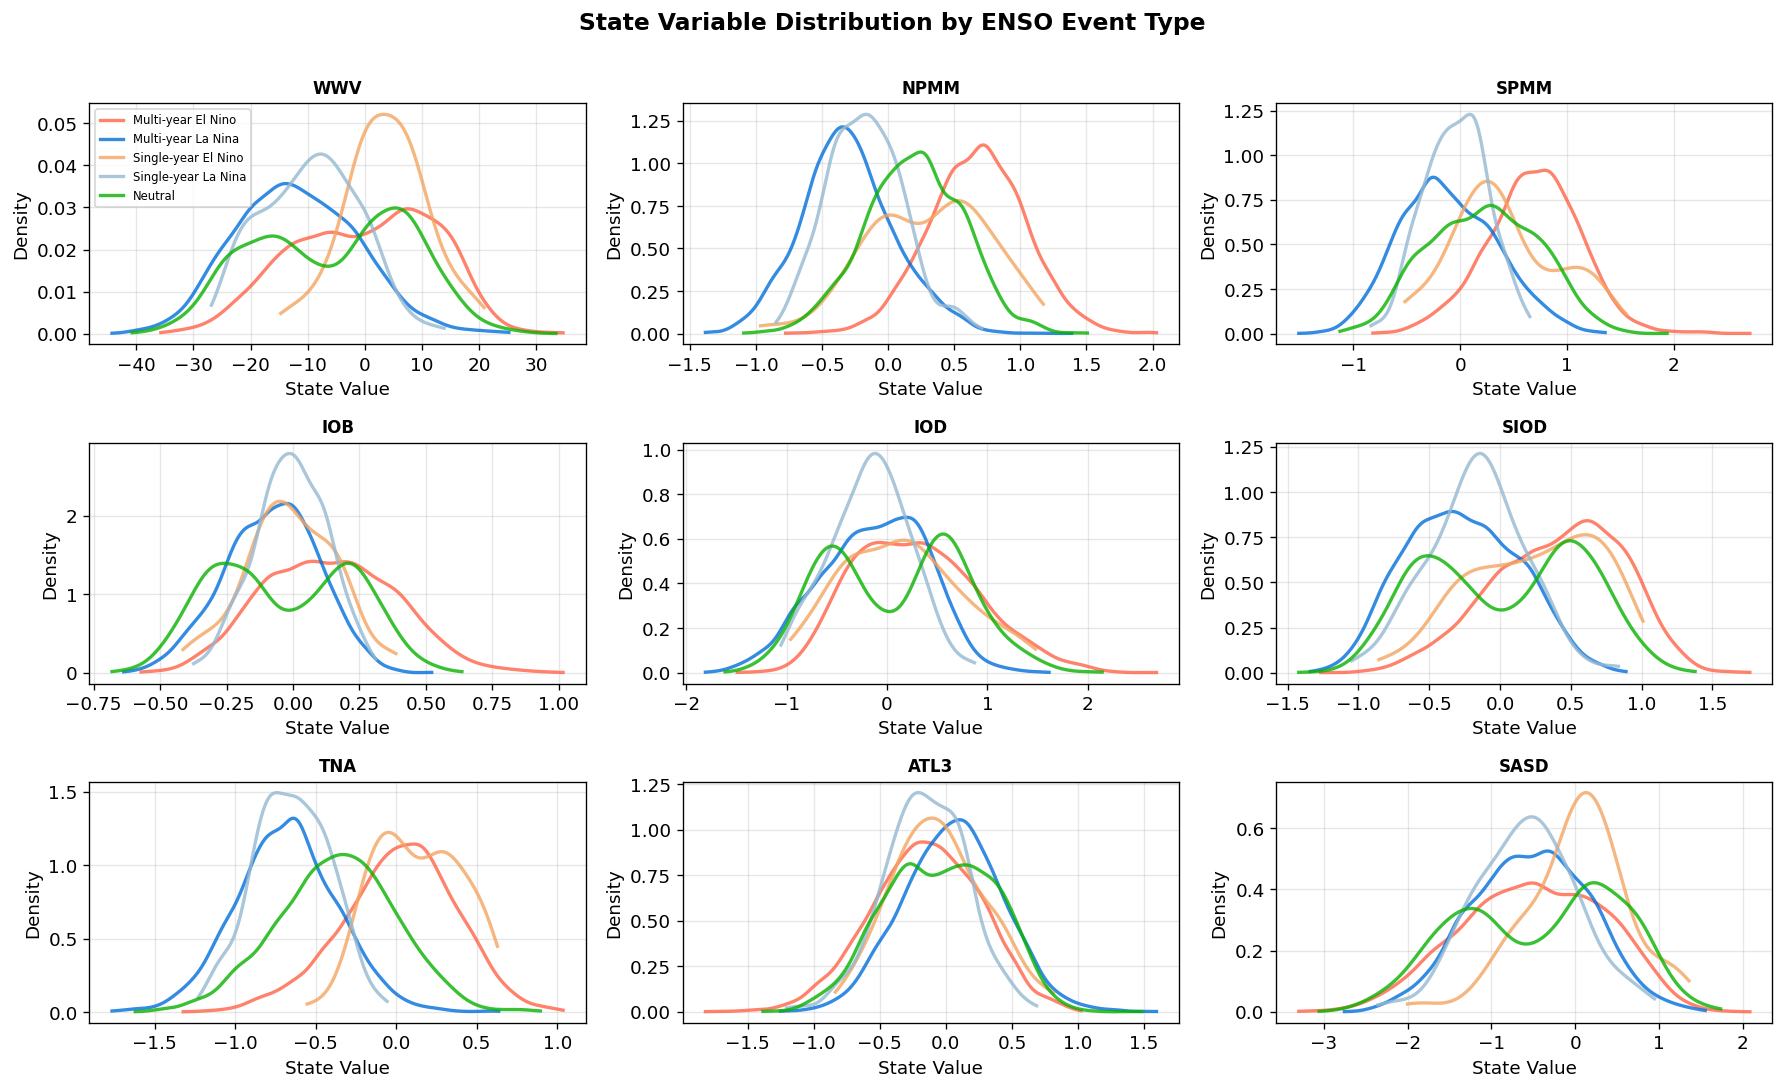

In [119]:
all_states = d_inf['agent_obs'].reshape(-1, len(traj_var_names))[:,1:] # slice to skip Nino34
_kde_grid_by_event(all_states, traj_var_names[1:],
                   "State Variable Distribution by ENSO Event Type", "State Value")

### Agent action distribution per mode

KDE of the agent's **raw** control action (∈ [−1, 1], storage-time scaling undone)
for each of the 9 forcing modes, over all seeds × rollouts × months. Shows how hard
and in which direction (sign) the agent pushes each driver.

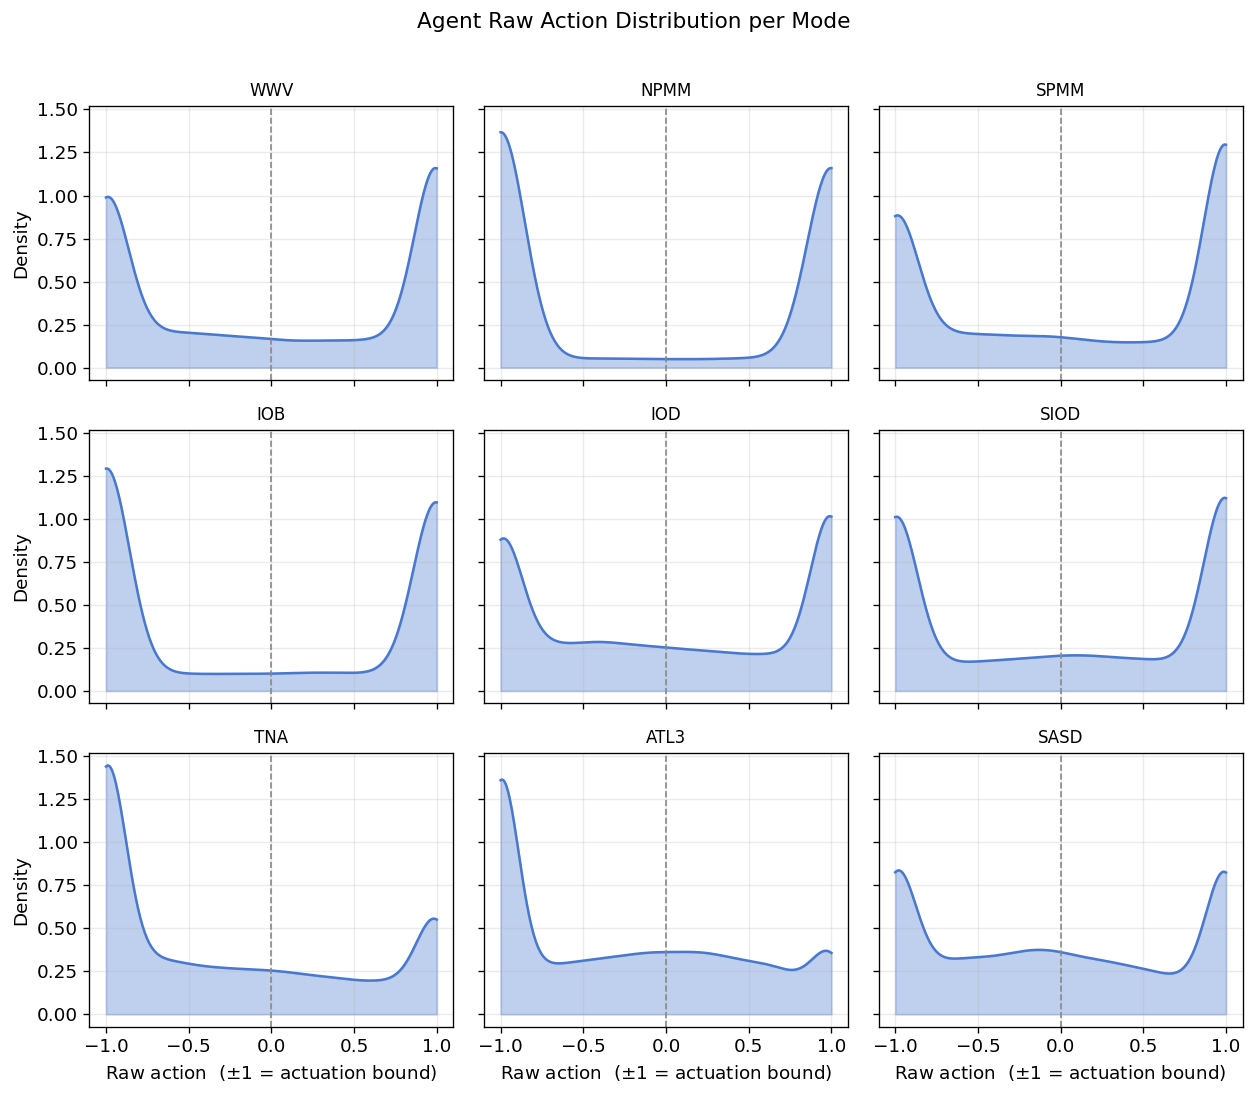

In [120]:
# Plot in paper
# --- 5b. Per-mode KDE of the agent's raw action (effort + direction) ---
from scipy.stats import gaussian_kde

# inference.py stores the raw policy action directly (schema v2); no unscaling here.
raw9     = d_inf['agent_actions_raw']                  # [n_seeds,n_rollouts,T,9] in [-1,1]
assert np.abs(raw9).max() <= 1.001, "raw action outside [-1,1] -- stale npz?"
raw_flat = raw9.reshape(-1, 9)

rng_a = np.random.default_rng(0)
idx_a = rng_a.choice(raw_flat.shape[0], min(50_000, raw_flat.shape[0]), replace=False)

# sharex/sharey: every panel is a density of the SAME quantity on the SAME [-1, 1]
# domain, and peak densities differ by only ~1.4x across modes, so shared axes cost
# nothing and let the reader compare how sharply bimodal each mode is. The y-axis was
# previously blanked with set_yticks([]), which left the panels unreadable as densities
# -- a reader could not tell whether a taller peak meant more mass or a different scale.
fig, axes = plt.subplots(3, 3, figsize=(3 * 3.5, 3 * 3), sharex=True, sharey=True)
for ai, aname in enumerate(traj_action_names):
    ax   = axes.ravel()[ai]
    vals = raw_flat[idx_a, ai]
    xs   = np.linspace(vals.min(), vals.max(), 300)
    kde  = gaussian_kde(vals, bw_method=0.15)
    ax.fill_between(xs, kde(xs), alpha=0.35, color="#4878CF")
    ax.plot(xs, kde(xs), color="#4878CF", linewidth=1.5)
    ax.axvline(0, color="#888888", linestyle="--", linewidth=1)   # no-action reference
    ax.set_title(aname, fontsize=10)
    ax.grid(alpha=0.25)

# One axis label per edge rather than nine repeats.
for ax in axes[:, 0]:
    ax.set_ylabel("Density")
for ax in axes[-1, :]:
    ax.set_xlabel("Raw action  ($\\pm1$ = actuation bound)")

fig.suptitle("Agent Raw Action Distribution per Mode", fontsize=13, y=1.01)
fig.tight_layout()
save_fig(fig, BASE / "05b_action_kde_per_mode.png")
save_fig(fig, FIGS / "action.png")
plt.show()

In [121]:
# Reuse already-loaded d_inf (inference.npz) for seasonality.
# Use agent_actions_raw (the policy output in [-1, 1]) rather than agent_actions
# (physical forcing), so effort is comparable across modes whose scales differ ~10x.

raw_actions = d_inf['agent_actions_raw']    # [n_seeds, n_rollouts, T, 9] in [-1, 1]
n_modes = raw_actions.shape[-1]
drivers = list(d_inf['action_names'])       # 9 forcing modes (no Nino3.4)
T_seas  = raw_actions.shape[2]
SPINUP_seas = int(d_inf['spinup'])          # == 12

# Per-rollout calendar month of step 0. reset() starts the seasonal clock at the
# sampled state's month (not January), so we must bin by the TRUE calendar month
# (step + start_month) % 12, not step % 12. Guaranteed present by schema v2.
start_month = d_inf['rollout_start_month']              # [n_seeds, n_rollouts]

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
spring_idx  = [2, 3, 4]


# Bin RAW action by TRUE calendar month per rollout, skipping the SPINUP transient.
keep = np.arange(T_seas) >= SPINUP_seas
abs_by_month    = np.full((n_seeds_inf, n_rollouts_inf, 12, n_modes), np.nan)
signed_by_month = np.full((n_seeds_inf, n_rollouts_inf, 12, n_modes), np.nan)
for si in range(n_seeds_inf):
    for ri in range(n_rollouts_inf):
        cal_month = (np.arange(T_seas) + int(start_month[si, ri])) % 12
        for m in range(12):
            sel = keep & (cal_month == m)
            if sel.any():
                abs_by_month[si, ri, m, :]    = np.abs(raw_actions[si, ri, sel, :]).mean(0)
                signed_by_month[si, ri, m, :] = raw_actions[si, ri, sel, :].mean(0)

# Ensemble mean over seeds x rollouts (nanmean guards a month a short rollout may miss)
abs_mean    = np.nanmean(abs_by_month, axis=(0, 1))      # [12, n_modes]
signed_mean = np.nanmean(signed_by_month, axis=(0, 1))   # [12, n_modes]
total_by_month = abs_mean.sum(axis=1)                    # [12]

spring_frac = total_by_month[spring_idx].sum() / total_by_month.sum()
print(f"Spring (Mar-May) share: {spring_frac*100:.1f}%  (even = 25.0%)")
print(f"Modes: {drivers}")

Spring (Mar-May) share: 25.6%  (even = 25.0%)
Modes: [np.str_('WWV'), np.str_('NPMM'), np.str_('SPMM'), np.str_('IOB'), np.str_('IOD'), np.str_('SIOD'), np.str_('TNA'), np.str_('ATL3'), np.str_('SASD')]


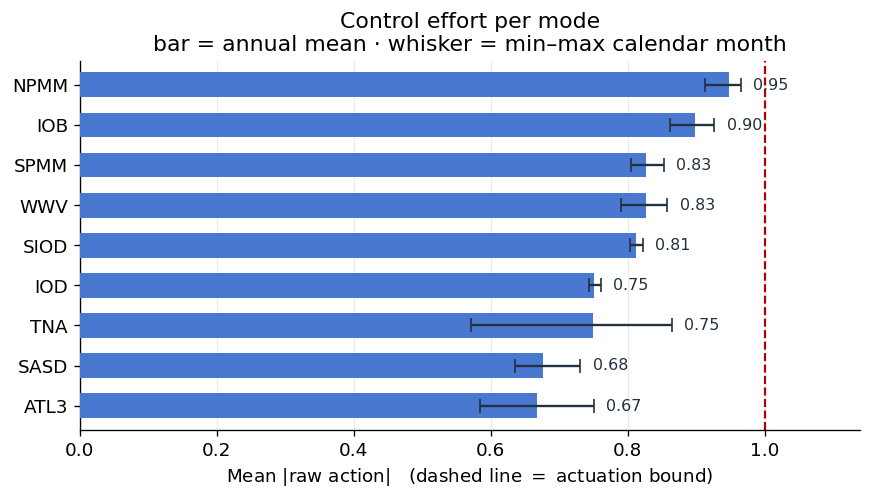

annual-mean |raw action|: 0.668 (ATL3) to 0.948 (NPMM)
seasonal swing (max-min month): largest 0.294 (TNA), median across modes 0.064


In [122]:
# Plot in paper
# --- 4a. Control effort per mode (annual mean + calendar-month range) ---
# Replaces the month x mode heatmap. Seven of the nine modes vary by <=0.03 across
# the whole calendar year (~3% of the actuation bound), so a 12 x 9 grid spent a
# large display on a null result, and forced a choice between an autoscaled colour
# map that manufactured seasonal structure and a [0, 1] map that went uniformly
# flat. A bar on a zero-based axis carries all three claims at once: the effort
# level (bars read against the bound), the mode ranking, and the seasonal
# amplitude. The whisker is the min->max calendar month, i.e. a FULL RANGE, not a
# confidence interval -- it cannot shrink with more seeds. Say so in the caption.
BLUE, INK = "#4878CF", "#22303F"
eff_mean = abs_mean.mean(axis=0)           # [n_modes] annual mean
eff_lo   = abs_mean.min(axis=0)            # weakest calendar month
eff_hi   = abs_mean.max(axis=0)            # strongest calendar month
order    = np.argsort(eff_mean)            # ascending -> largest plots on top

fig, ax = plt.subplots(figsize=(7.4, 4.3))
y = np.arange(n_modes)
ax.barh(y, eff_mean[order], height=0.62, color=BLUE, zorder=3)
ax.errorbar(eff_mean[order], y,
            xerr=[eff_mean[order] - eff_lo[order], eff_hi[order] - eff_mean[order]],
            fmt="none", ecolor=INK, elinewidth=1.4, capsize=4, zorder=4)
ax.axvline(1.0, color="#B10000", lw=1.3, ls="--", zorder=2)      # actuation bound
for i, j in enumerate(order):
    ax.text(eff_hi[j] + 0.018, i, f"{eff_mean[j]:.2f}", ha="left", va="center",
            color=INK, fontsize=9.5, zorder=5)
ax.set_yticks(y); ax.set_yticklabels([drivers[j] for j in order])
ax.set_ylim(-0.6, n_modes - 0.4)
ax.set_xlim(0, 1.14); ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_xlabel("Mean $|$raw action$|$   (dashed line $=$ actuation bound)")
ax.set_title("Control effort per mode\n"
             "bar = annual mean \u00b7 whisker = min\u2013max calendar month")
ax.grid(axis="x", alpha=0.25, zorder=0); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.tight_layout()
# save_fig(fig, FIGS / "seasonality.png")
plt.show()

swing = eff_hi - eff_lo
print(f"annual-mean |raw action|: {eff_mean.min():.3f} ({drivers[int(eff_mean.argmin())]}) "
      f"to {eff_mean.max():.3f} ({drivers[int(eff_mean.argmax())]})")
print(f"seasonal swing (max-min month): largest {swing.max():.3f} "
      f"({drivers[int(swing.argmax())]}), median across modes {np.median(swing):.3f}")


---
## Extended Data — single-rollout state & action time series

Illustrative full time series of all 10 state modes and 9 control actions for the
representative rollout selected in §2.2.1 (`SEED_IDX`, `ROLLOUT_IDX`).

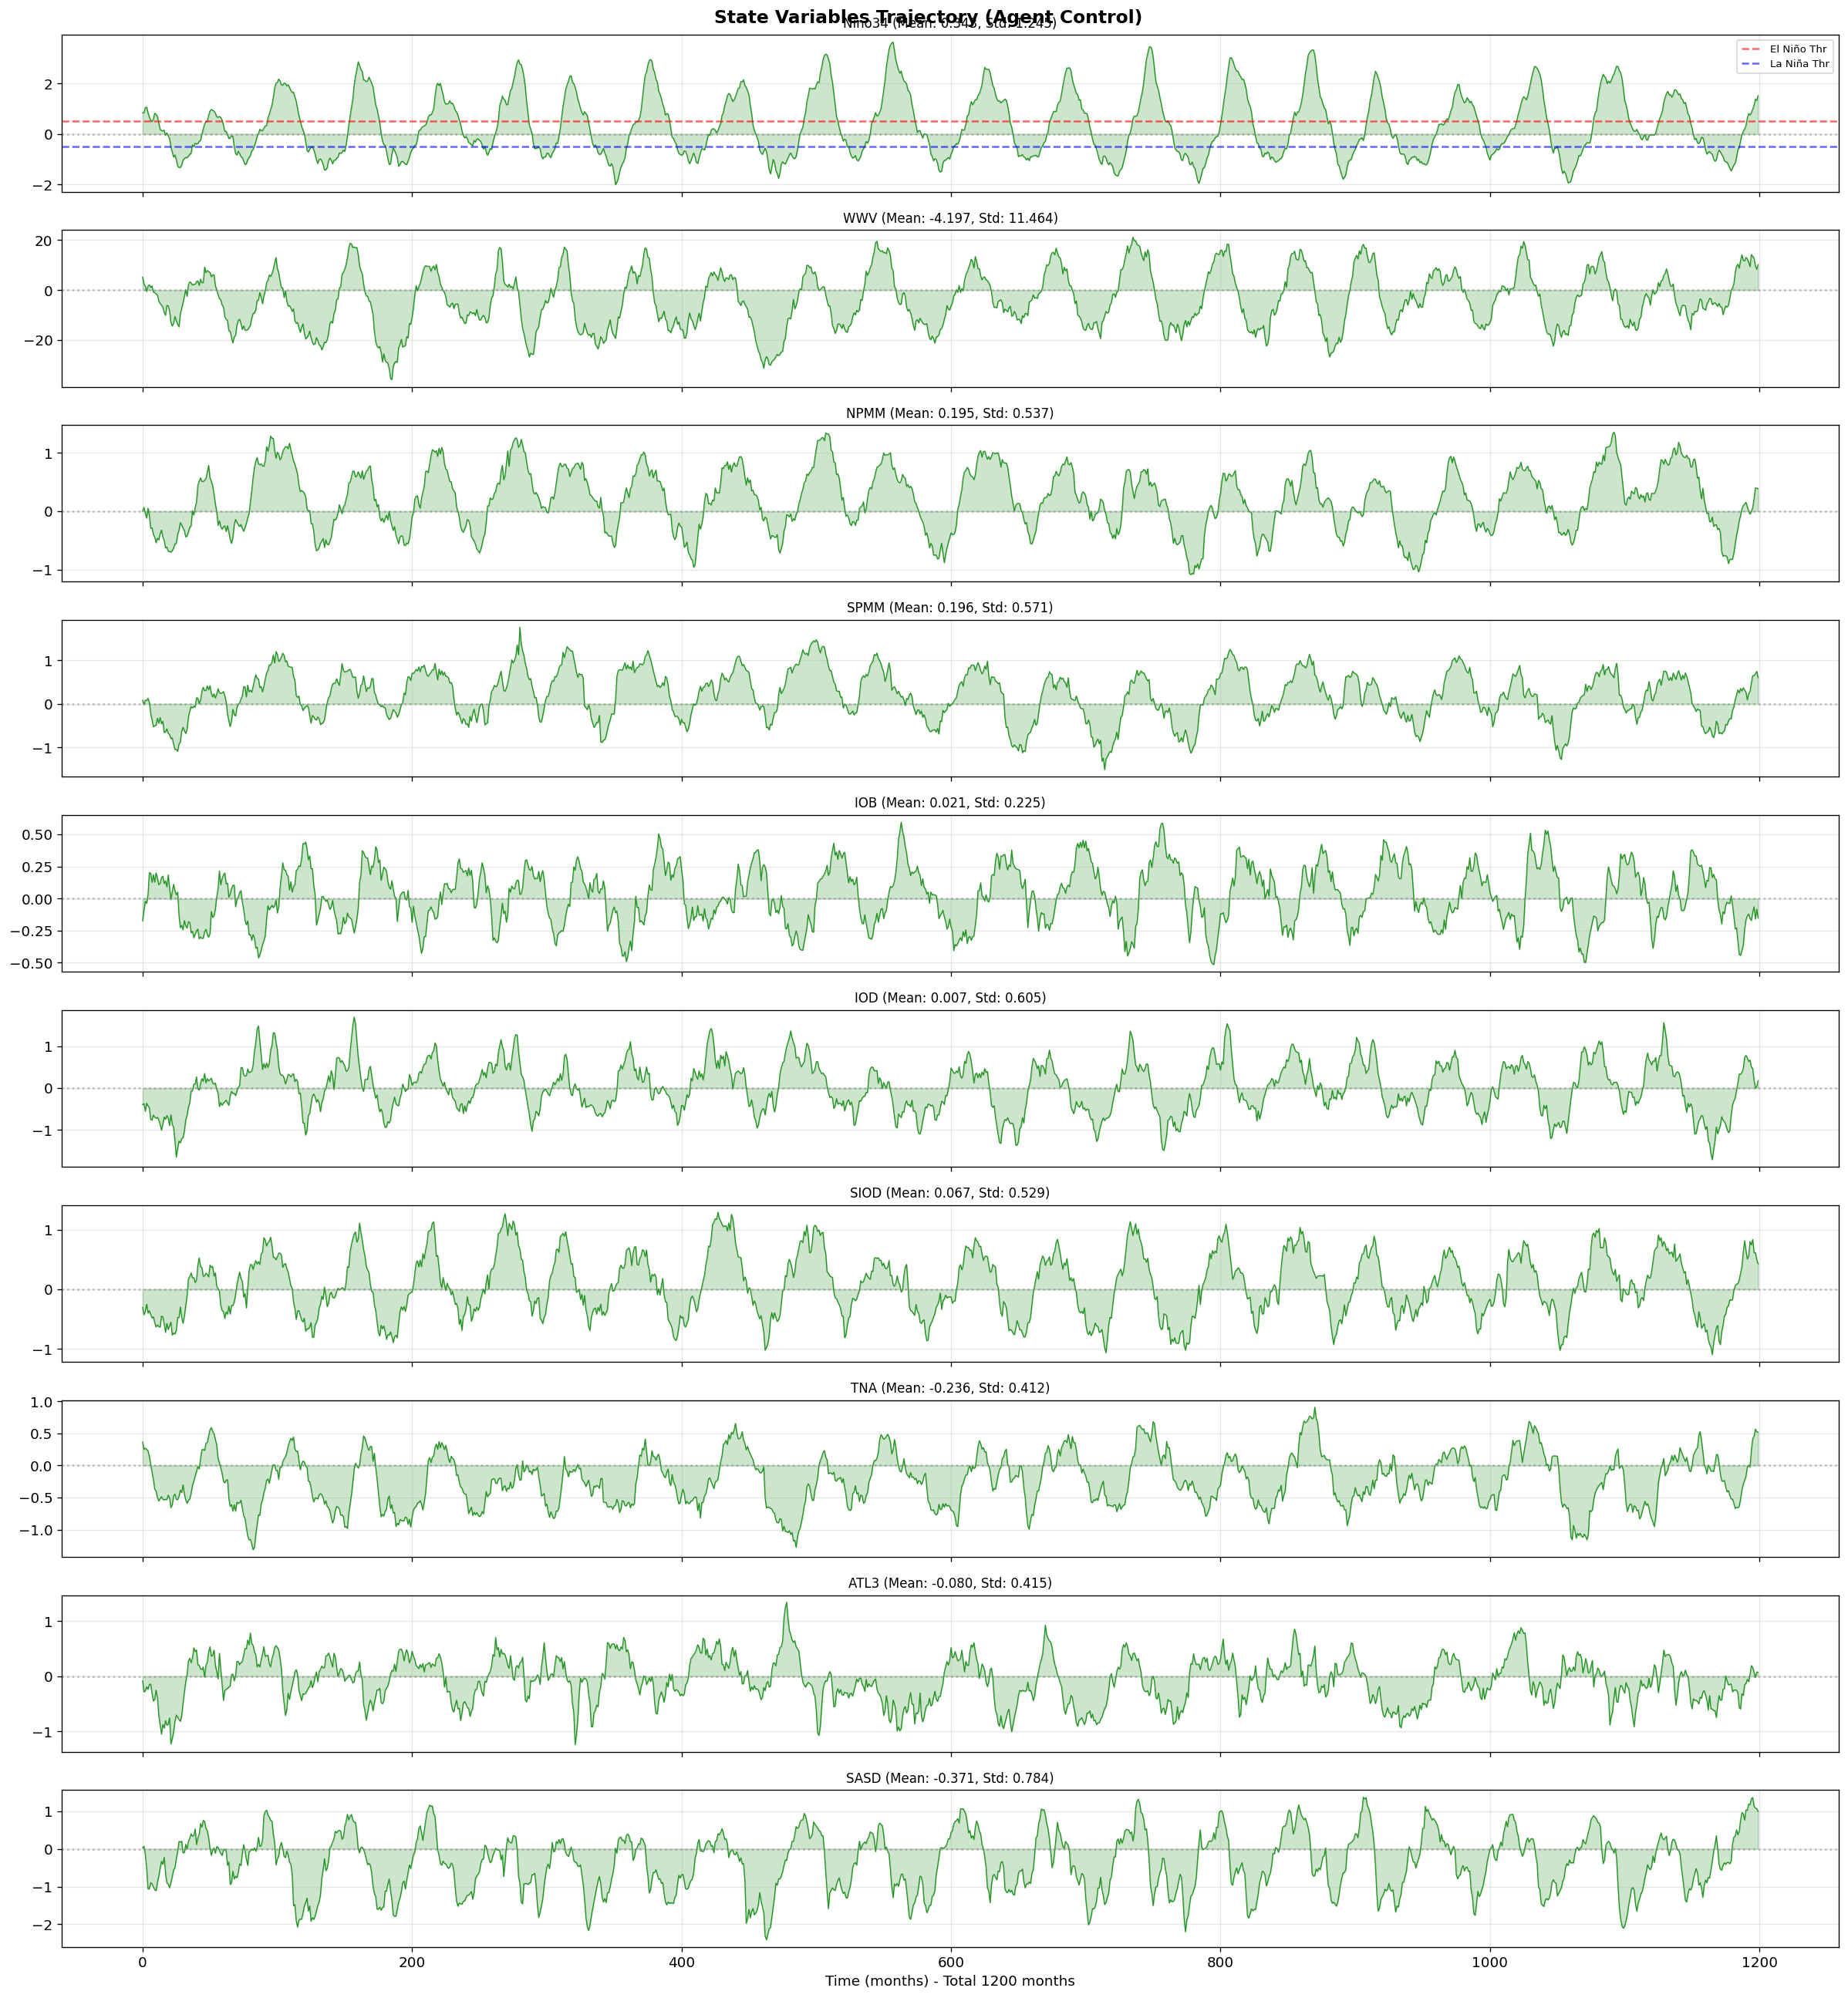

In [123]:
n_vars = len(traj_var_names)
fig, axes = plt.subplots(n_vars, 1, figsize=(20, n_vars * 2.2), sharex=True)
fig.suptitle("State Variables Trajectory (Agent Control)", fontsize=14, fontweight='bold')

for i, vname in enumerate(traj_var_names):
    ax = axes[i]
    ax.plot(states_traj[:, i], linewidth=0.8, color='green', alpha=0.8)
    ax.fill_between(range(T_traj), states_traj[:, i], alpha=0.2, color='green')
    if vname == 'Nino34':
        ax.axhline(THRESHOLD,  color='r', linestyle='--', alpha=0.6, label='El Niño Thr')
        ax.axhline(-THRESHOLD, color='b', linestyle='--', alpha=0.6, label='La Niña Thr')
        ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{vname} (Mean: {states_traj[:, i].mean():.3f}, Std: {states_traj[:, i].std():.3f})',
                 fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

axes[-1].set_xlabel(f"Time (months) - Total {T_traj} months")
fig.tight_layout()
plt.show()

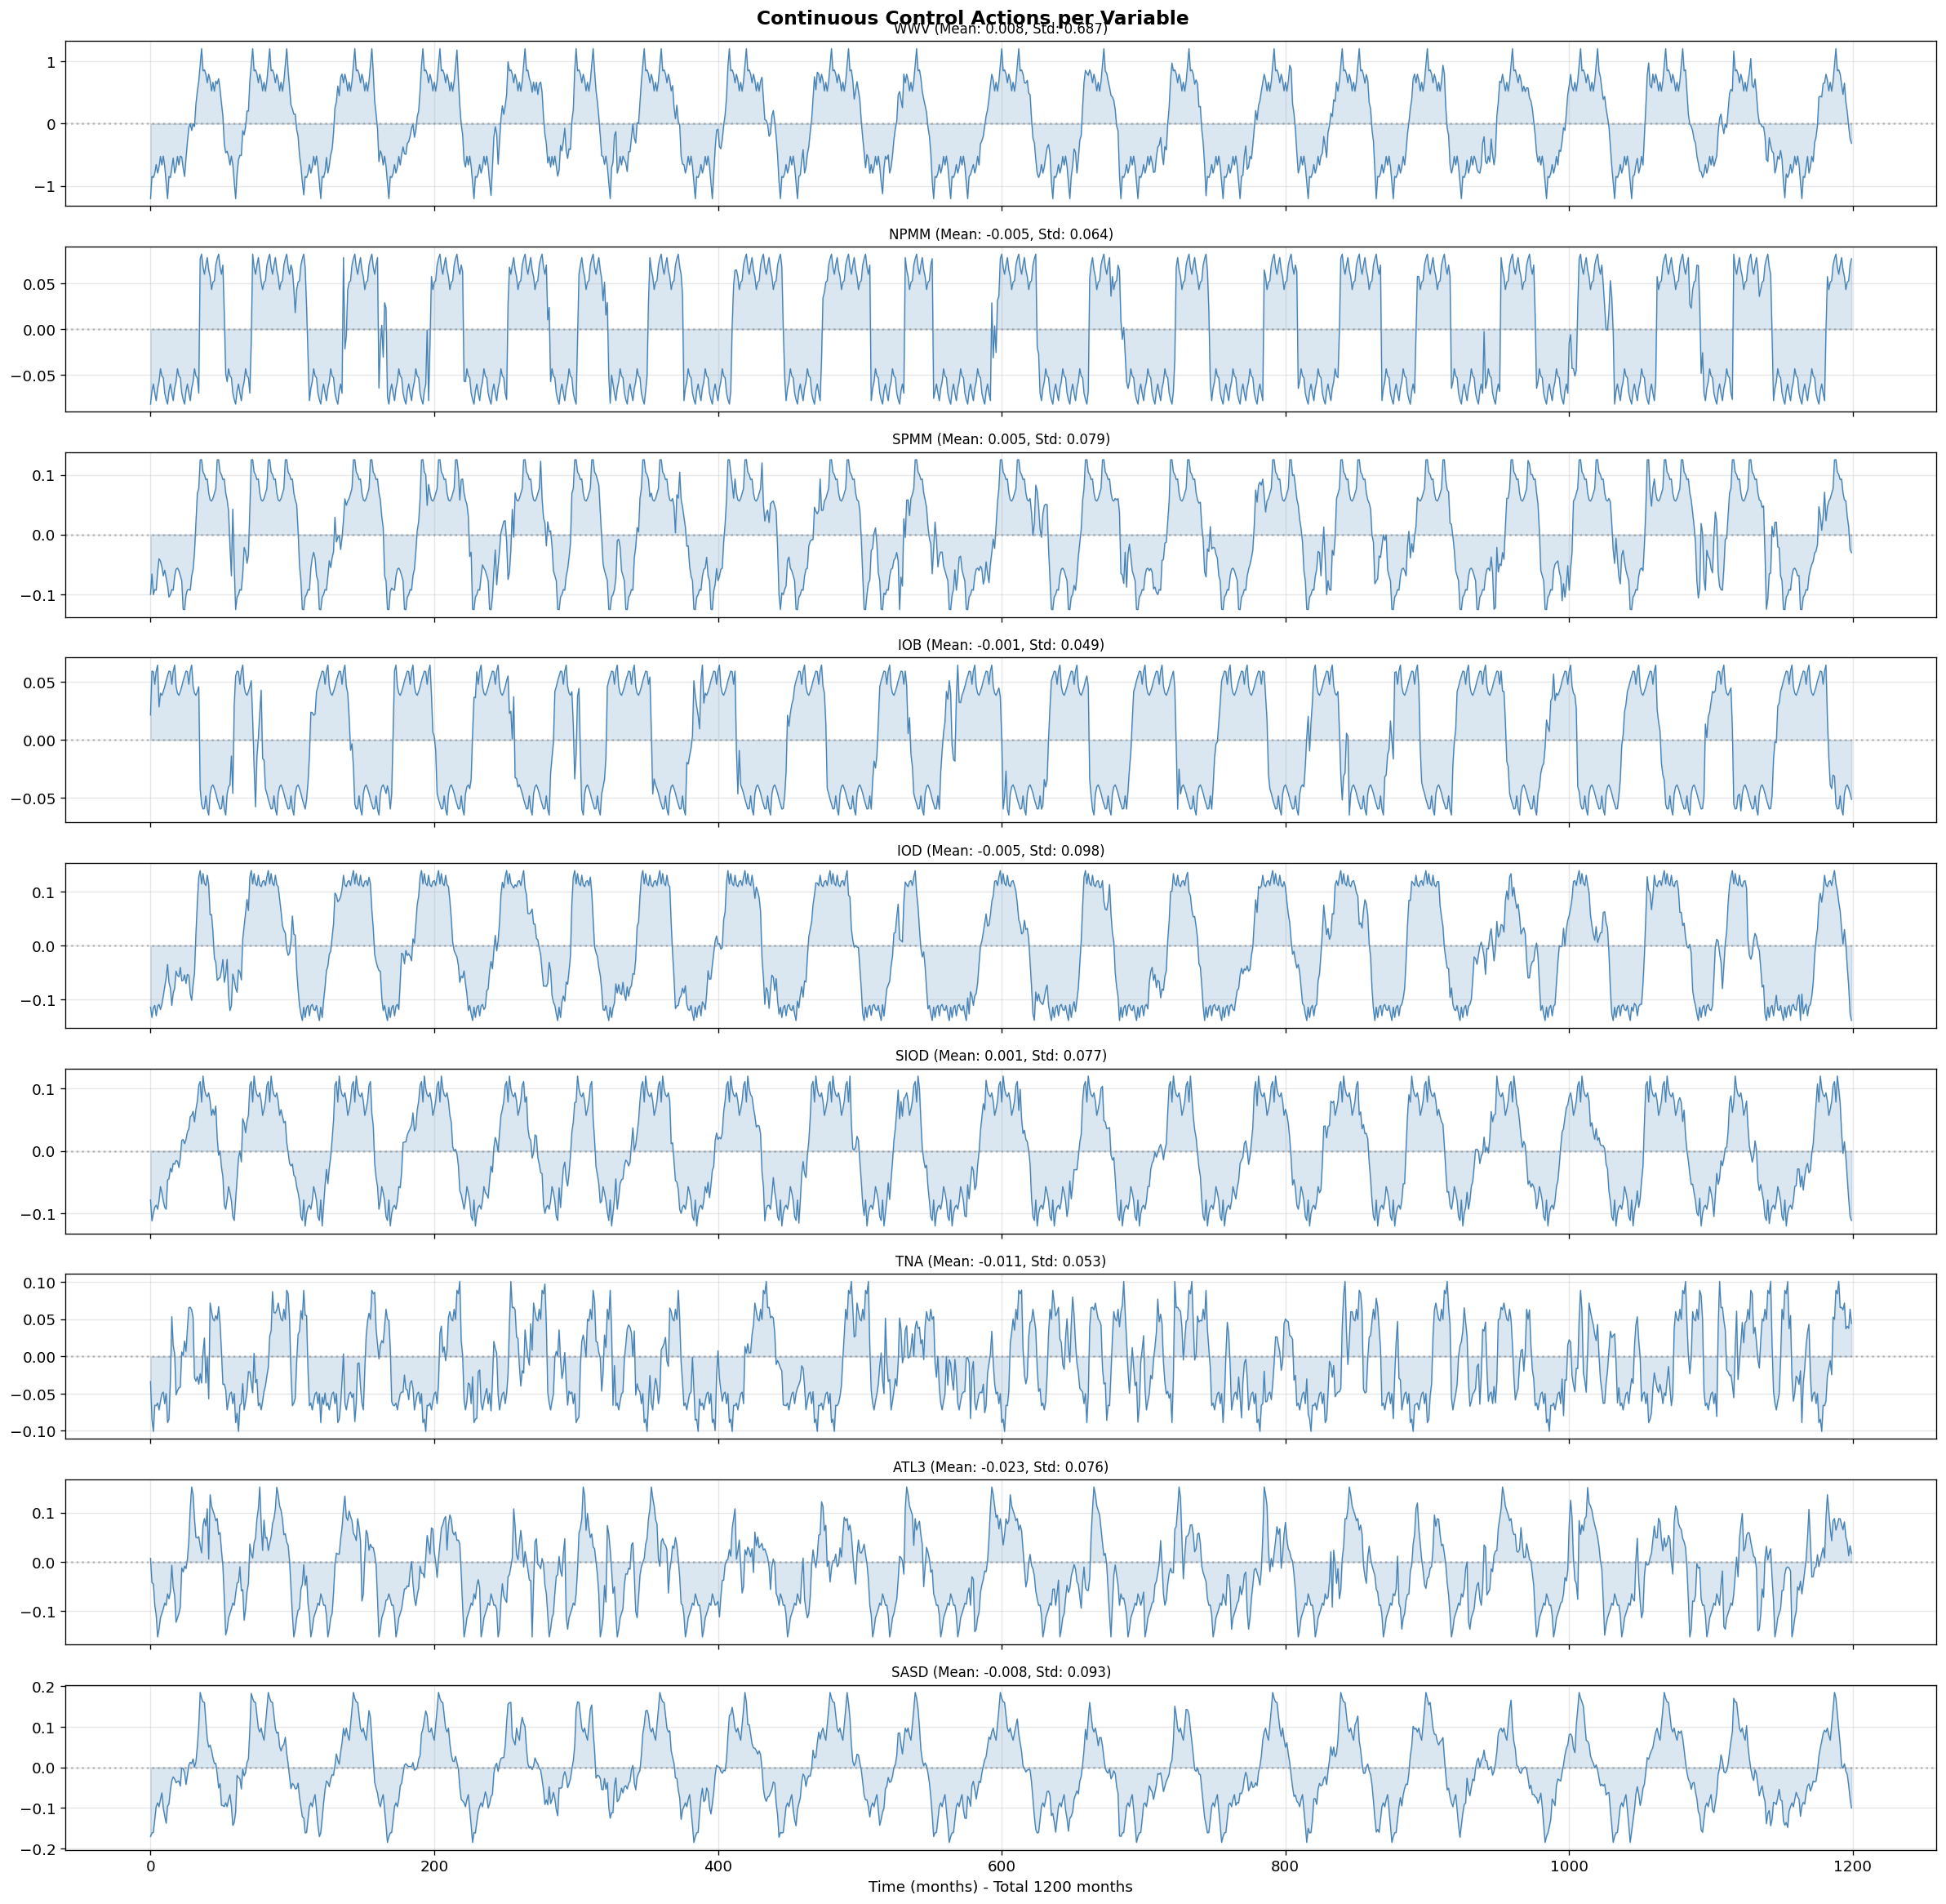

In [124]:
n_act = len(traj_action_names)
fig, axes = plt.subplots(n_act, 1, figsize=(20, n_act * 2.2), sharex=True)
fig.suptitle("Continuous Control Actions per Variable (raw, $\\pm$1 = actuation bound)",
             fontsize=14, fontweight='bold')

for i, vname in enumerate(traj_action_names):
    ax = axes[i]
    ax.plot(raw_traj[:, i], linewidth=0.8, color='steelblue')
    ax.fill_between(range(T_traj), raw_traj[:, i], alpha=0.2, color='steelblue')
    ax.set_title(f'{vname} (Mean: {raw_traj[:, i].mean():.3f}, Std: {raw_traj[:, i].std():.3f})',
                 fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

axes[-1].set_xlabel(f"Time (months) - Total {T_traj} months")
fig.tight_layout()
plt.show()

## Niño3.4 power spectrum — agent vs baseline vs observations

Frequency-domain view of the frequency-driven / multi-year result: the agent concentrates Niño3.4 variance into a **sharp ~4–5 yr peak** near the observed ENSO band, while the free-running baseline is broad and too slow (~7 yr). The agent's peak is *narrower than observations* — i.e. control makes ENSO **more regular than nature** (worth stating honestly). Exploratory — not saved to figs/.

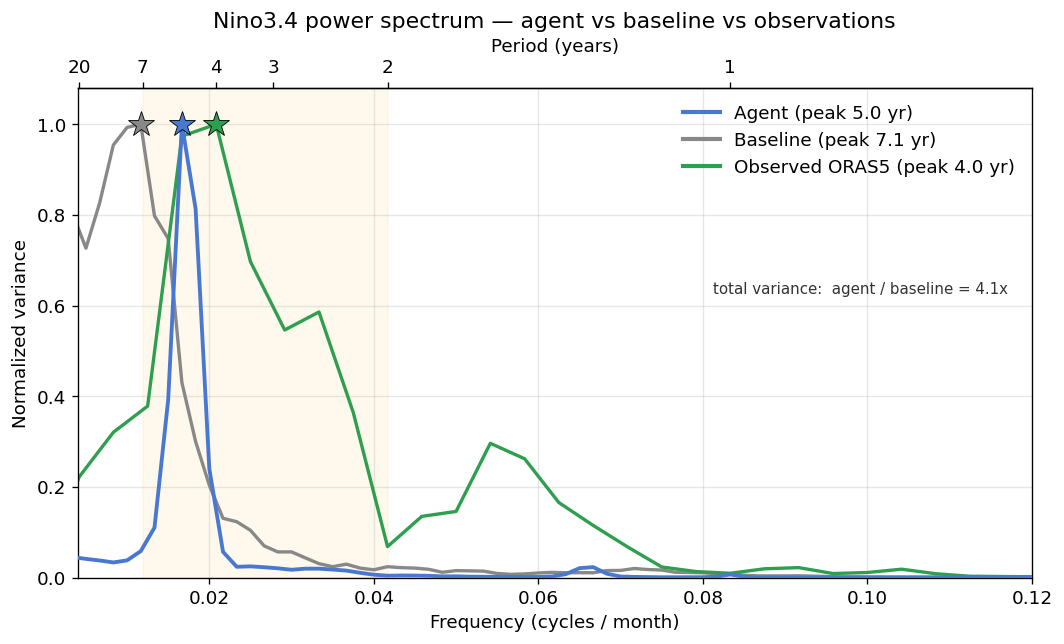

In [125]:
# Niño3.4 power spectrum — agent vs baseline vs observed ORAS5 (exploratory; not saved)
from scipy.signal import welch
from config import EnvConfig
from utils.data_processing import load_observational_data
from matplotlib.lines import Line2D

d_spec = load_inference(BASE / "inference.npz")
spin   = int(d_spec["spinup"])
nino_a = d_spec["agent_obs"][..., 0][:, :, spin:]     # [S,R,T] agent Nino3.4
nino_b = d_spec["base_obs"][..., 0][:, :, spin:]      # baseline
NPERSEG = 600

def _seed_psd(x):
    """Welch PSD per (seed,rollout), averaged within each seed -> [n_seeds, n_freq]."""
    ns = min(NPERSEG, x.shape[2])
    f  = welch(x[0, 0], fs=1.0, nperseg=ns)[0]
    per_seed = [np.mean([welch(x[si, ri], fs=1.0, nperseg=ns, detrend="constant")[1]
                         for ri in range(x.shape[1])], axis=0)
                for si in range(x.shape[0])]
    return f, np.array(per_seed)

f, Pa = _seed_psd(nino_a)
_, Pb = _seed_psd(nino_b)

_ec = EnvConfig()
# data_path is repo-root-relative; the notebook runs from notebooks/, so prefix with ".."
_dpath = str((Path("..") / _ec.data_config["data_path"]).resolve())
_o, _train_ds, _vn, _bd = load_observational_data(
    _dpath, _ec.data_config["train_start"], _ec.data_config["train_end"])
obs = np.asarray(_train_ds[_vn[0]].values, float); obs = obs[np.isfinite(obs)]
fo, Po = welch(obs, fs=1.0, nperseg=min(240, len(obs)), detrend="constant")

def _peak_yr(fg, p):
    i = int(np.argmax(p[1:]) + 1)
    return 1.0 / fg[i] / 12.0, fg[i]

med_a = np.median(Pa, 0); q25a, q75a = np.percentile(Pa, [25, 75], 0)
med_b = np.median(Pb, 0)
pk_a, fa = _peak_yr(f, med_a); pk_b, fb = _peak_yr(f, med_b); pk_o, fo_ = _peak_yr(fo, Po)
var_ratio = Pa.mean(0).sum() / Pb.mean(0).sum()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axvspan(1/(7*12), 1/(2*12), color="orange", alpha=0.07, zorder=0)          # ENSO band 2-7 yr
ax.fill_between(f, q25a/med_a.max(), q75a/med_a.max(), color="#4878CF", alpha=0.18, zorder=1)
ax.plot(f, med_a/med_a.max(), color="#4878CF", lw=2.3, zorder=3)
ax.plot(f, med_b/med_b.max(), color="#888888", lw=2.0, zorder=2)
ax.plot(fo, Po/Po.max(),      color="#2E9E4F", lw=2.0, zorder=2)
for fx, col in ((fa, "#4878CF"), (fb, "#888888"), (fo_, "#2E9E4F")):
    ax.plot(fx, 1.0, marker="*", ms=16, color=col, mec="black", mew=0.5, zorder=6, clip_on=False)

ax.set_xlim(0.004, 0.12); ax.set_ylim(0, 1.08)
ax.set_xlabel("Frequency (cycles / month)"); ax.set_ylabel("Normalized variance")
ax.set_title("Nino3.4 power spectrum — agent vs baseline vs observations")
leg = [Line2D([0],[0], color="#4878CF", lw=2.5, label=f"Agent (peak {pk_a:.1f} yr)"),
       Line2D([0],[0], color="#888888", lw=2.5, label=f"Baseline (peak {pk_b:.1f} yr)"),
       Line2D([0],[0], color="#2E9E4F", lw=2.5, label=f"Observed ORAS5 (peak {pk_o:.1f} yr)")]
ax.legend(handles=leg, frameon=False, loc="upper right")
ax.text(0.975, 0.58, f"total variance:  agent / baseline = {var_ratio:.1f}x",
        transform=ax.transAxes, ha="right", fontsize=9, color="#333333")
_g = lambda x: 1.0 / np.clip(np.asarray(x, float), 1e-9, None) / 12.0
sec = ax.secondary_xaxis("top", functions=(_g, _g)); sec.set_xlabel("Period (years)")
sec.set_xticks([20, 7, 4, 3, 2, 1])
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## (Option 3) Niño3.4 vs each mode — coherence & phase at the ENSO peak

Phase lead in months (+ = the mode peaks *before* Niño3.4). Sign validated against a time-domain lagged cross-correlation: WWV leads Niño3.4 by ~13 mo (baseline) / ~9 mo (agent) — the recharge oscillator, reproduced by the model and preserved (tightened) under control. Note: modes that are *anti*-correlated with Niño3.4 (e.g. ATL3, SASD) have a ±half-cycle phase ambiguity, so read their lead/lag cautiously. Saved to `figs/mode_phase_lead.png`.

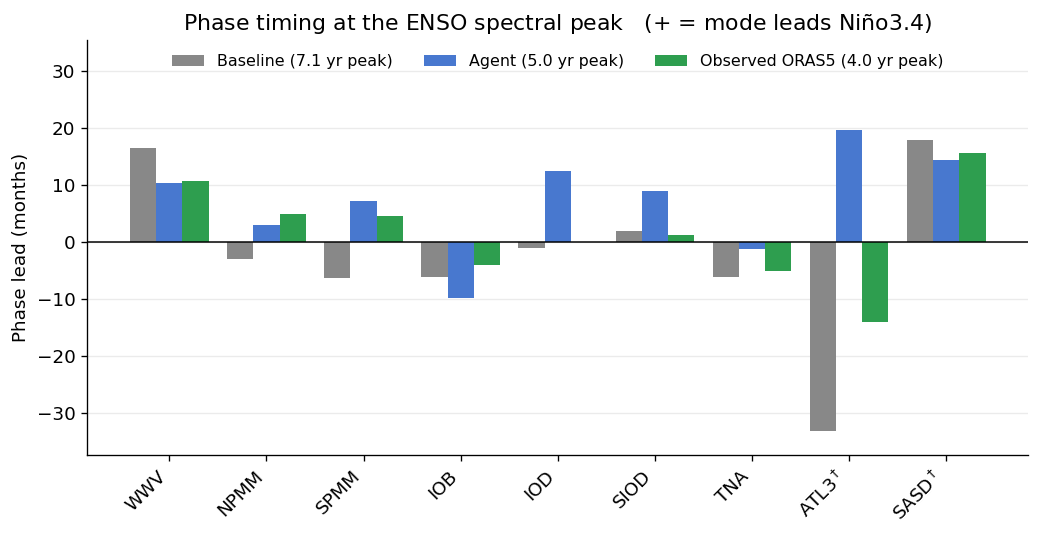

mode    baseline    agent    ORAS5   phase lead (months)
WWV         16.5     10.3     10.6
NPMM        -3.1      3.0      5.0
SPMM        -6.3      7.2      4.5
IOB         -6.1     -9.9     -4.0
IOD         -1.0     12.4     -0.1
SIOD         2.0      8.9      1.2
TNA         -6.1     -1.3     -5.2
ATL3       -33.2     19.6    -14.0
SASD        17.9     14.3     15.6

mean coherence at the peak: agent 0.97 | baseline 0.72 | observed 0.68


In [126]:
# Option 3: coherence + phase lead of each mode vs Ni\u00f1o3.4 at the ENSO peak
# THREE series: zero-action baseline, agent, and the observed ORAS5 record, each
# evaluated at ITS OWN ENSO spectral peak with the identical estimator. The observed
# bars are the reference the whole comparison rests on; they previously existed only
# as numbers in the text, which left the figure unable to show whether the agent moved
# a mode toward or away from nature.
from scipy.signal import welch, csd, coherence
from config import EnvConfig
from utils.data_processing import load_observational_data

d3 = load_inference(BASE / "inference.npz"); spin = int(d3["spinup"]); vn3 = list(d3["var_names"])
A3 = d3["agent_obs"][:, :, spin:, :]; B3 = d3["base_obs"][:, :, spin:, :]
S3, R3, T3, M3 = A3.shape; ns3 = min(600, T3)

def _coh_phase(X, nperseg):
    """Per mode (vs Nino3.4=col0): coherence & phase-lead (months) at that run's ENSO peak.

    X: [n_seeds, n_rollouts, T, n_modes]. Observations are passed as a single
    [1, 1, T, n_modes] record so one code path serves all three series.
    """
    S, R, T, M = X.shape
    acc = [welch(X[si, ri, :, 0], fs=1.0, nperseg=nperseg, detrend="constant")[1]
           for si in range(S) for ri in range(R)]
    fg = welch(X[0, 0, :, 0], fs=1.0, nperseg=nperseg)[0]
    ip = int(np.argmax(np.mean(acc, 0)[1:]) + 1); fpk = fg[ip]
    lead, coh = [], []
    for k in range(1, M):
        Pxy = np.zeros(len(fg), complex); C = np.zeros(len(fg))
        for si in range(S):
            for ri in range(R):
                Pxy += csd(X[si, ri, :, k], X[si, ri, :, 0], fs=1.0, nperseg=nperseg, detrend="constant")[1]
                C   += coherence(X[si, ri, :, k], X[si, ri, :, 0], fs=1.0, nperseg=nperseg, detrend="constant")[1]
        # NB: numpy FFT sign convention -> negate so (+) = mode LEADS Nino3.4.
        # Validated against time-domain lagged cross-correlation: baseline WWV leads by
        # ~13 mo, agent WWV by ~9 mo, consistent with the recharge oscillator.
        lead.append(-np.angle(Pxy[ip]) / (2 * np.pi * fpk))   # months; + = mode leads Nino3.4
        coh.append(C[ip] / (S * R))
    return np.array(lead), np.array(coh), 1.0 / fpk / 12.0

lead_a, coh_a, yr_a = _coh_phase(A3, ns3)
lead_b, coh_b, yr_b = _coh_phase(B3, ns3)

# Observed ORAS5, same estimator. The record is 528 months, so nperseg must be below the
# 600 used for the 1188-month rollouts; 240 matches what the spectrum cell uses for obs.
# The observed peak therefore sits on a coarser frequency grid -- say so in the caption.
_ec3 = EnvConfig()
_dp3 = str((Path("..") / _ec3.data_config["data_path"]).resolve())
_, _tds3, _vno3, _ = load_observational_data(
    _dp3, _ec3.data_config["train_start"], _ec3.data_config["train_end"])
O3 = np.stack([np.asarray(_tds3[v].values, float) for v in _vno3], axis=-1)[None, None]
NS_OBS = 240
lead_o, coh_o, yr_o = _coh_phase(O3, NS_OBS)

modes3 = vn3[1:]; x3 = np.arange(len(modes3)); w = 0.27
GREY, BLUE, GREEN = "#888888", "#4878CF", "#2E9E4F"   # GREEN matches the spectrum figure
fig, ax2 = plt.subplots(figsize=(8.8, 4.6))
ax2.axhline(0, color="black", lw=0.9, zorder=3)
ax2.bar(x3 - w, lead_b, w, color=GREY,  label=f"Baseline ({yr_b:.1f} yr peak)", zorder=2)
ax2.bar(x3,     lead_a, w, color=BLUE,  label=f"Agent ({yr_a:.1f} yr peak)", zorder=2)
ax2.bar(x3 + w, lead_o, w, color=GREEN, label=f"Observed ORAS5 ({yr_o:.1f} yr peak)", zorder=2)
# dagger = anti-correlated with Nino3.4 -> +/- half-cycle phase ambiguity (see caption)
lab3 = [m + r"$^\dagger$" if m in ("ATL3", "SASD") else m for m in modes3]
ax2.set_xticks(x3); ax2.set_xticklabels(lab3, rotation=45, ha="right")
ax2.set_ylabel("Phase lead (months)")
ax2.set_title("Phase timing at the ENSO spectral peak   ($+$ = mode leads Ni\u00f1o3.4)")
_lo = min(lead_a.min(), lead_b.min(), lead_o.min())
_hi = max(lead_a.max(), lead_b.max(), lead_o.max())
ax2.set_ylim(_lo - 0.08 * (_hi - _lo), _hi + 0.30 * (_hi - _lo))   # headroom for the legend
ax2.legend(frameon=False, ncol=3, loc="upper center", fontsize=9.5)
ax2.grid(axis="y", alpha=0.25, zorder=0); ax2.set_axisbelow(True)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
fig.tight_layout()
save_fig(fig, FIGS / "mode_phase_lead.png")
plt.show()

print(f"{'mode':6s} {'baseline':>9s} {'agent':>8s} {'ORAS5':>8s}   phase lead (months)")
for i, m in enumerate(modes3):
    print(f"{m:6s} {lead_b[i]:9.1f} {lead_a[i]:8.1f} {lead_o[i]:8.1f}")
print(f"\nmean coherence at the peak: agent {coh_a.mean():.2f} | "
      f"baseline {coh_b.mean():.2f} | observed {coh_o.mean():.2f}")


## Spectral regime analysis

Log-period axis + variance-density normalisation ($E_k^2/\sum E_k^2$). Shows how Niño3.4 variance is *distributed* across timescales, the Decadal/Interannual/Quasibiennial partition, and the collapse of per-rollout regimes. **Caveat:** the interannual concentration is partly by construction (the reward targets multi-year events); the observations overlay is the realism check. Exploratory — not saved.

In [127]:
# --- shared setup for the spectral regime panels (A, B, C) ---
from scipy.signal import welch
from config import EnvConfig
from utils.data_processing import load_observational_data

dS = load_inference(BASE / "inference.npz"); spin = int(dS["spinup"])
Ag = dS["agent_obs"][:, :, spin:, 0]; Bl = dS["base_obs"][:, :, spin:, 0]   # Nino3.4 [S,R,T]

def _per(f):                                  # frequency -> period (years)
    return 1.0 / np.where(f == 0, np.nan, f) / 12.0

def _peaknorm_seedbands(X, nperseg=600):
    """Peak-normalised spectra (each rollout scaled so its max = 1) per seed -> f, median/q25/q75.
    Peak-normalisation compares SHAPE and PEAK LOCATION fairly across curves of very different
    concentration and bin count; the variance MAGNITUDE / fractions live in panel B."""
    ns = min(nperseg, X.shape[2]); f = welch(X[0, 0], fs=1.0, nperseg=ns)[0]
    per_seed = [np.mean([(lambda P: P / P.max())(welch(X[si, ri], fs=1.0, nperseg=ns, detrend="constant")[1])
                         for ri in range(X.shape[1])], 0) for si in range(X.shape[0])]
    M = np.array(per_seed)
    return f, np.median(M, 0), np.percentile(M, 25, 0), np.percentile(M, 75, 0)

def _norm(f, P, how="varpres"):
    """One normalisation convention applied to a single Welch spectrum.
    varpres: f*P/var -> variance fraction per unit ln(period); on the log-period axis the
             AREA under the curve is the fraction of that series' variance (total = 1).
    area:    P/var   -> density, integrates to 1 over frequency (area meaningful on a LINEAR axis).
    abs:     raw P   -> degC^2 per (cycle/month), no normalisation at all.
    varpres_common: f*P with NO division -> same variance-preserving shape, but in absolute
             degC^2, so peak HEIGHT is comparable between agent / baseline / observed."""
    if how == "abs":
        return P
    if how == "varpres_common":                        # absolute f*P, NO per-curve division:
        return f * P                                   # heights/areas comparable across curves (degC^2)
    var = P.sum() * (f[1] - f[0])                      # Parseval: integral of the density = variance
    return f * P / var if how == "varpres" else P / var

def _specnorm_seedbands(X, how="varpres", nperseg=600):
    """Normalised spectra per rollout -> mean within a seed -> median/q25/q75 across seeds.
    Each curve is divided by its OWN variance, so the y-axis is a fraction and shapes are
    comparable across systems of very different magnitude (magnitude lives in the legend sigma^2)."""
    ns = min(nperseg, X.shape[2]); f = welch(X[0, 0], fs=1.0, nperseg=ns)[0]
    per_seed = np.array([np.mean([_norm(f, welch(X[si, ri], fs=1.0, nperseg=ns, detrend="constant")[1], how)
                                  for ri in range(X.shape[1])], 0) for si in range(X.shape[0])])
    return f, np.median(per_seed, 0), np.percentile(per_seed, 25, 0), np.percentile(per_seed, 75, 0)

def _band_partition(X, nperseg=600):
    """% of variance in Decadal(>7y)/Interannual(2-7y)/Quasibiennial(<2y): mean, SE over (seed,rollout)."""
    ns = min(nperseg, X.shape[2]); rows = []
    for si in range(X.shape[0]):
        for ri in range(X.shape[1]):
            f, P = welch(X[si, ri], fs=1.0, nperseg=ns, detrend="constant"); per = _per(f)
            dec, ia, qb = P[per > 7].sum(), P[(per >= 2) & (per <= 7)].sum(), P[(per < 2) & (per > 0)].sum()
            tot = dec + ia + qb; rows.append([dec/tot, ia/tot, qb/tot])
    r = np.array(rows) * 100; return r.mean(0), r.std(0) / np.sqrt(len(r))

def _dom_periods(X, nperseg=300):
    ns = min(nperseg, X.shape[2])
    return np.array([1.0 / welch(X[si, ri], fs=1.0, nperseg=ns, detrend="constant")[0]
                     [int(np.argmax(welch(X[si, ri], fs=1.0, nperseg=ns, detrend="constant")[1][1:]) + 1)] / 12.0
                     for si in range(X.shape[0]) for ri in range(X.shape[1])])

# observed ORAS5 Nino3.4
_ec = EnvConfig()
_dp = Path(_ec.data_config["data_path"])          # relative to repo root
if not _dp.exists():                              # notebook cwd is notebooks/ -> look one level up
    _dp = Path("..") / _dp
_o, _tr, _vn, _bd = load_observational_data(str(_dp),
                                            _ec.data_config["train_start"], _ec.data_config["train_end"])
obs = np.asarray(_tr[_vn[0]].values, float); obs = obs[np.isfinite(obs)]
fo, Po = welch(obs, fs=1.0, nperseg=min(240, len(obs)), detrend="constant")


print("spectral setup ready")


spectral setup ready


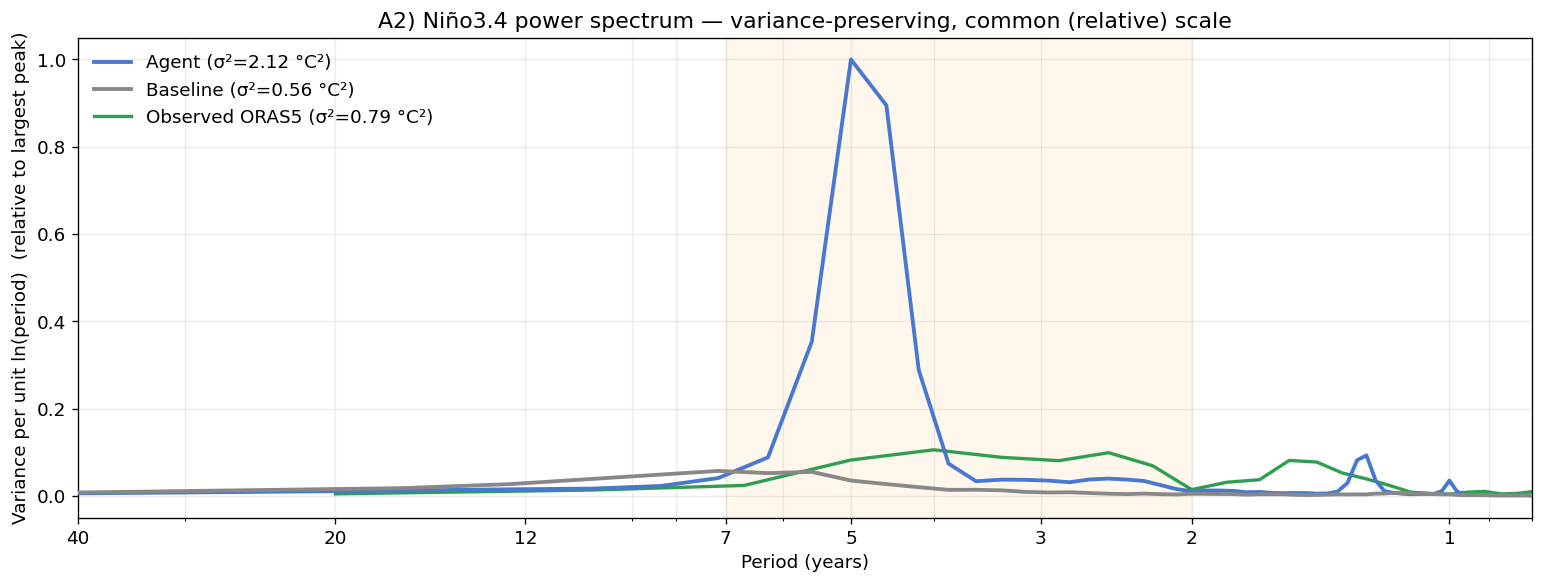

peak  agent 1.000 | baseline 0.057 | observed 0.106 (rel)   ->  agent/baseline = 17.5x, agent/observed = 9.5x  (ratios identical in both SCALE modes)


In [128]:
# A2) Same variance-preserving spectrum, but on ONE common scale (no per-curve division).
# Panel A divides every curve by its own variance -> it answers "what SHAPE", and the height
# gap there (6.9x) is only concentration. Here f*P is left on a shared scale, so height and
# area are comparable between curves and the real magnitude gap (35x) is what you see.
HOW2  = "varpres_common"
SCALE = "rel"      # "abs" = absolute degC^2 | "rel" = every curve / the single largest peak (ratios unchanged)
fa, ma, qa1, qa2 = _specnorm_seedbands(Ag, how=HOW2)
fb, mb, qb1, qb2 = _specnorm_seedbands(Bl, how=HOW2)
mo = _norm(fo, Po, HOW2)
va, vb, vo = Ag.var(-1).mean(), Bl.var(-1).mean(), obs.var()
D = max(ma.max(), mb.max(), mo.max()) if SCALE == "rel" else 1.0   # ONE divisor for all three curves
fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(2, 7, color="orange", alpha=0.08, zorder=0)
for pf, m, q1, q2, col, lab in [(fa, ma, qa1, qa2, "#4878CF", f"Agent (σ²={va:.2f} °C²)"),
                                (fb, mb, qb1, qb2, "#888888", f"Baseline (σ²={vb:.2f} °C²)")]:
    per = _per(pf)
    ax.fill_between(per, q1 / D, q2 / D, color=col, alpha=0.20, zorder=1)
    ax.plot(per, m / D, color=col, lw=2.3, label=lab, zorder=3)
ax.plot(_per(fo), mo / D, color="#2E9E4F", lw=2.0,
        label=f"Observed ORAS5 (σ²={vo:.2f} °C²)", zorder=2)
ax.set_xscale("log"); ax.set_xlim(40, 0.8)
ax.set_xticks([40, 20, 12, 7, 5, 3, 2, 1]); ax.set_xticklabels([40, 20, 12, 7, 5, 3, 2, 1])
ax.set_xlabel("Period (years)")
ax.set_ylabel("Variance per unit ln(period)  (°C²)" if SCALE == "abs" else
              "Variance per unit ln(period)  (relative to largest peak)")
ax.set_title(f"A2) Niño3.4 power spectrum — variance-preserving, common "
             f"{'(absolute) ' if SCALE == 'abs' else '(relative) '}scale")
ax.legend(frameon=False, loc="upper left"); ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
save_fig(fig, FIGS / "nino_power_spectrum.png")
plt.show()

# observed uses a 240-mo Welch segment vs 600 for the model runs -> slightly smoother / lower
print(f"peak  agent {ma.max()/D:.3f} | baseline {mb.max()/D:.3f} | observed {mo.max()/D:.3f}"
      f"{' °C²' if SCALE == 'abs' else ' (rel)'}   ->  agent/baseline = {ma.max()/mb.max():.1f}x, "
      f"agent/observed = {ma.max()/mo.max():.1f}x  (ratios identical in both SCALE modes)")

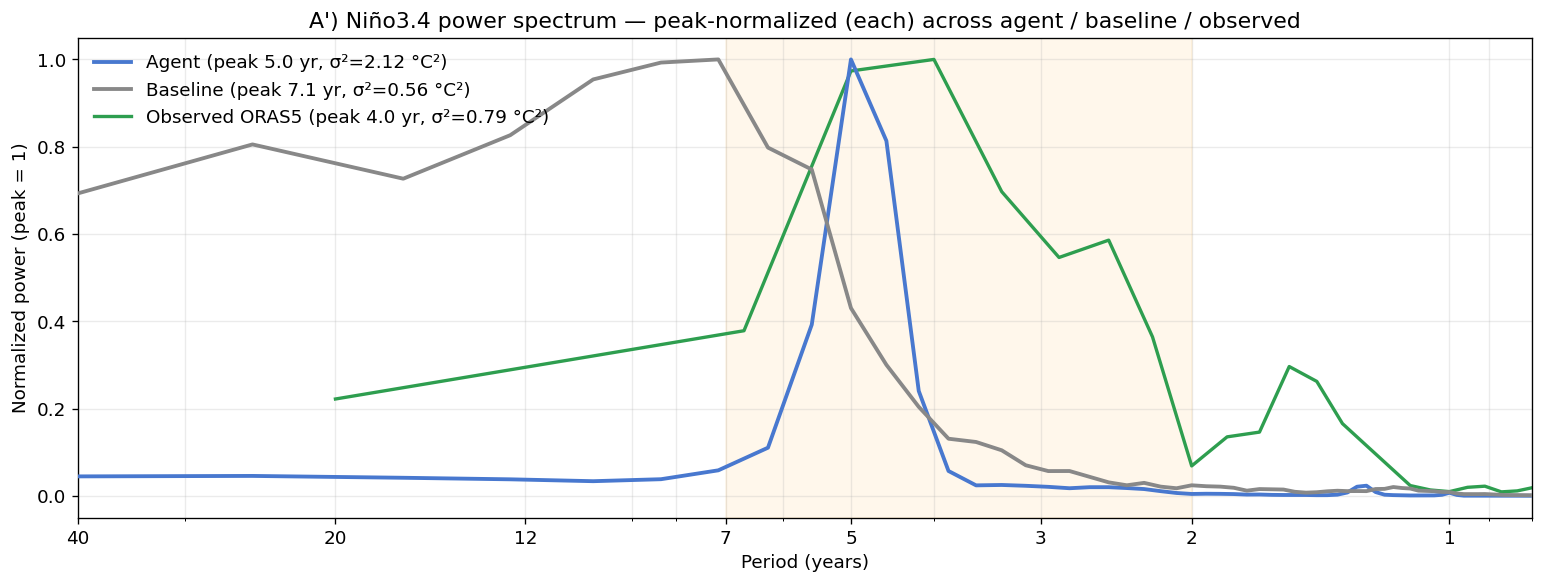

peak-height ratio agent/baseline = 12.2x  (suppressed by PKMODE="each")


In [129]:
# A') Peak-normalised Niño3.4 spectra — one convention applied to all three curves
# Peak-norm answers WHERE the peak sits and HOW SHARP it is; it deliberately discards
# magnitude (the agent's peak is ~26x the baseline's). Variance fractions live in panel B.
# Normalise the density P, not f*P: the f-weighting exists to make AREA readable on a log
# axis, and under peak-norm area carries no meaning — it would only tilt every peak short.
PKMODE = "each"     # "each": every curve peaks at 1.0 | "global": all / the largest peak (relative heights survive)

def _rawseedbands(X, nperseg=600):
    """Welch density, un-normalised: mean over rollouts within a seed -> median/q25/q75 across seeds."""
    ns = min(nperseg, X.shape[2]); f = welch(X[0, 0], fs=1.0, nperseg=ns)[0]
    per_seed = np.array([np.mean([welch(X[si, ri], fs=1.0, nperseg=ns, detrend="constant")[1]
                                  for ri in range(X.shape[1])], 0) for si in range(X.shape[0])])
    return f, np.median(per_seed, 0), np.percentile(per_seed, 25, 0), np.percentile(per_seed, 75, 0)

fa, ma, qa1, qa2 = _rawseedbands(Ag)
fb, mb, qb1, qb2 = _rawseedbands(Bl)
va, vb, vo = Ag.var(-1).mean(), Bl.var(-1).mean(), obs.var()

if PKMODE == "each":                    # every curve to its own peak
    da, db, do = ma.max(), mb.max(), Po.max()
else:                                   # one common divisor — note obs uses a shorter Welch
    da = db = do = max(ma.max(), mb.max(), Po.max())   # segment (240 vs 600), so it sits slightly low

fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(2, 7, color="orange", alpha=0.08, zorder=0)
for f_, m, q1, q2, d, col, nm, v in [(fa, ma, qa1, qa2, da, "#4878CF", "Agent", va),
                                     (fb, mb, qb1, qb2, db, "#888888", "Baseline", vb)]:
    per = _per(f_); pk = per[int(np.argmax(m[1:]) + 1)]
    ax.fill_between(per, q1 / d, q2 / d, color=col, alpha=0.20, zorder=1)
    ax.plot(per, m / d, color=col, lw=2.3, zorder=3,
            label=f"{nm} (peak {pk:.1f} yr, σ²={v:.2f} °C²)")
pk_o = _per(fo)[int(np.argmax(Po[1:]) + 1)]
ax.plot(_per(fo), Po / do, color="#2E9E4F", lw=2.0, zorder=2,
        label=f"Observed ORAS5 (peak {pk_o:.1f} yr, σ²={vo:.2f} °C²)")
ax.set_xscale("log"); ax.set_xlim(40, 0.8)
ax.set_xticks([40, 20, 12, 7, 5, 3, 2, 1]); ax.set_xticklabels([40, 20, 12, 7, 5, 3, 2, 1])
ax.set_xlabel("Period (years)")
ax.set_ylabel("Normalized power (peak = 1)" if PKMODE == "each" else "Normalized power (common peak = 1)")
ax.set_title(f"A') Niño3.4 power spectrum — peak-normalized ({PKMODE}) across agent / baseline / observed")
ax.legend(frameon=False, loc="upper left"); ax.grid(True, which="both", alpha=0.25)
fig.tight_layout(); plt.show()

print(f"peak-height ratio agent/baseline = {ma.max() / mb.max():.1f}x"
      f"{'  (suppressed by PKMODE=\"each\")' if PKMODE == 'each' else '  (visible: curves share one divisor)'}")

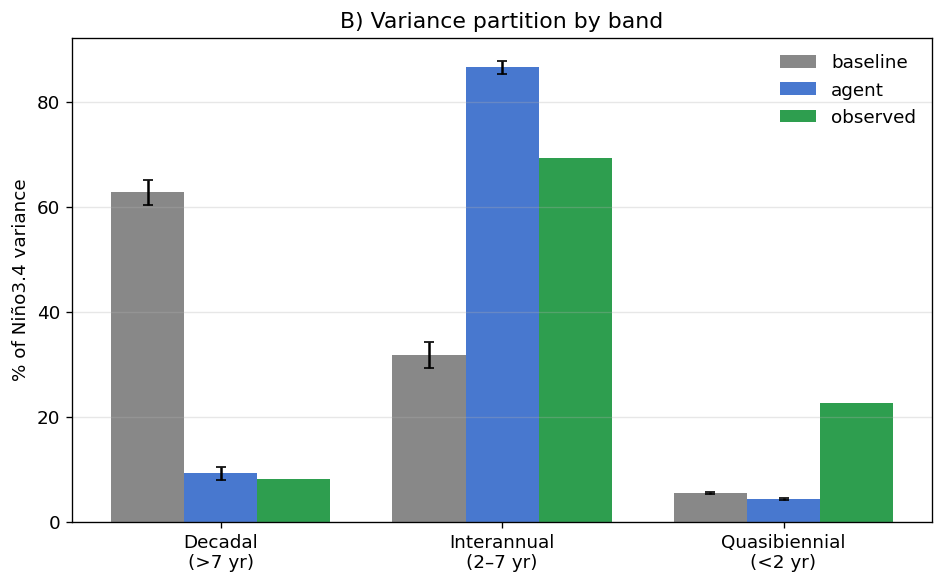

Interannual (2–7 yr): baseline 32%  agent 87%  observed 69%


In [130]:
# B) Variance partition into Decadal / Interannual / Quasibiennial bands
mb_, eb_ = _band_partition(Bl); ma_, ea_ = _band_partition(Ag)
op = np.array([Po[_per(fo) > 7].sum(), Po[(_per(fo) >= 2) & (_per(fo) <= 7)].sum(),
               Po[(_per(fo) < 2) & (_per(fo) > 0)].sum()]); op = op / op.sum() * 100
bands = ["Decadal\n(>7 yr)", "Interannual\n(2–7 yr)", "Quasibiennial\n(<2 yr)"]
x = np.arange(3); w = 0.26
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, mb_, w, yerr=eb_, color="#888888", capsize=3, label="baseline")
ax.bar(x,      ma_, w, yerr=ea_, color="#4878CF", capsize=3, label="agent")
ax.bar(x + w, op,  w, color="#2E9E4F", label="observed")
ax.set_xticks(x); ax.set_xticklabels(bands); ax.set_ylabel("% of Niño3.4 variance")
ax.set_title("B) Variance partition by band"); ax.legend(frameon=False); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()
print(f"Interannual (2–7 yr): baseline {mb_[1]:.0f}%  agent {ma_[1]:.0f}%  observed {op[1]:.0f}%")


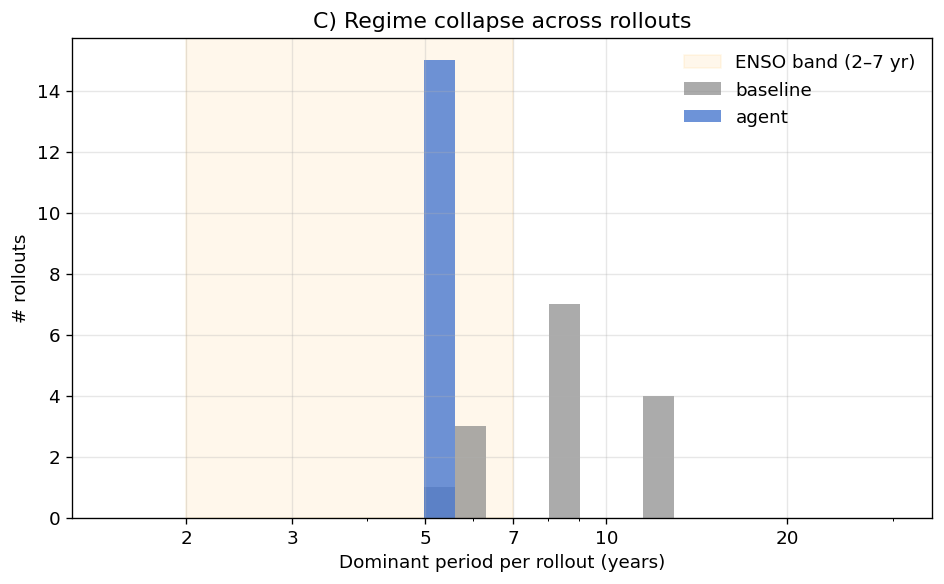

In [131]:
# C) Regime collapse — distribution of per-rollout dominant period
bins = np.logspace(np.log10(1.5), np.log10(30), 26)
fig, ax = plt.subplots(figsize=(8, 5))
ax.axvspan(2, 7, color="orange", alpha=0.08, zorder=0, label="ENSO band (2–7 yr)")
ax.hist(_dom_periods(Bl), bins=bins, color="#888888", alpha=0.7, label="baseline")
ax.hist(_dom_periods(Ag), bins=bins, color="#4878CF", alpha=0.8, label="agent")
ax.set_xscale("log"); ax.set_xticks([2, 3, 5, 7, 10, 20]); ax.set_xticklabels([2, 3, 5, 7, 10, 20])
ax.set_xlabel("Dominant period per rollout (years)"); ax.set_ylabel("# rollouts")
ax.set_title("C) Regime collapse across rollouts"); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


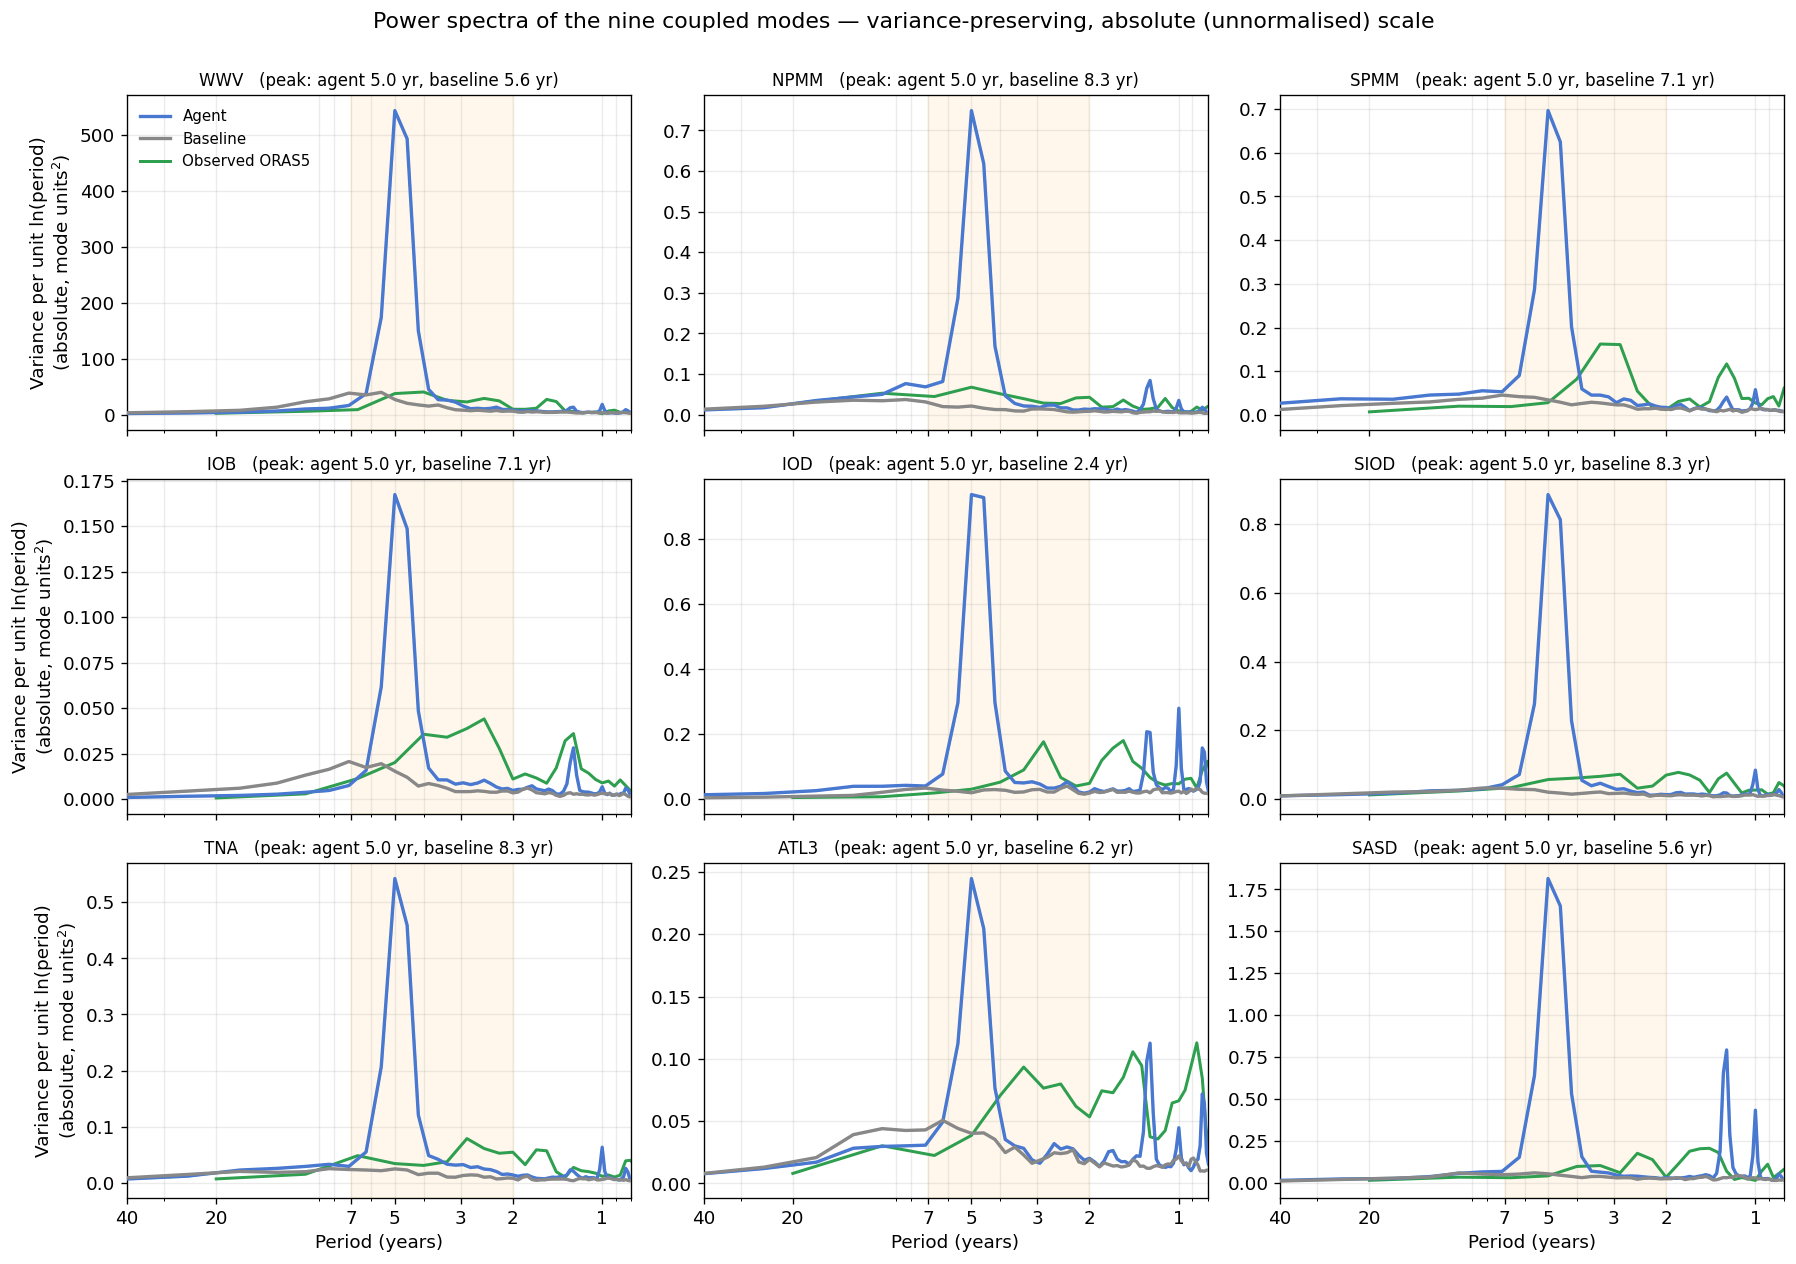

In [132]:
# D) Per-mode power spectra — same variance-preserving convention as A2, one panel per coupled mode.
# Niño3.4 is omitted (panels A/A2 cover it). PNORM picks how the three curves in a panel are scaled;
# note the modes carry different physical units, so only "panel" and "curve" give a shared y-axis.
HOW3 = "varpres_common"
PNORM = "abs"    # "panel": one divisor per panel  -> shared 0-1 axis, magnitudes honest within a mode
                   # "curve": each curve / its own peak -> shapes visible, magnitudes discarded
                   # "abs"  : no division at all        -> raw f*P in each mode's own units^2
A3 = dS["agent_obs"][:, :, spin:, :]; B3 = dS["base_obs"][:, :, spin:, :]
vn3 = list(dS["var_names"])
OBS3 = np.column_stack([np.asarray(_tr[v].values, float) for v in _vn])
OBS3 = OBS3[np.isfinite(OBS3).all(1)]                 # drop months missing in any mode
nso3 = min(240, len(OBS3))

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5), sharex=True, sharey=(PNORM != "abs"))
for ax, k in zip(axes.ravel(), range(1, len(vn3))):   # k = 0 is Nino3.4 -> skipped
    fa3, ma3, qa1, qa2 = _specnorm_seedbands(A3[:, :, :, k], how=HOW3)
    fb3, mb3, qb1, qb2 = _specnorm_seedbands(B3[:, :, :, k], how=HOW3)
    fo3, Po3 = welch(OBS3[:, k], fs=1.0, nperseg=nso3, detrend="constant")
    mo3 = _norm(fo3, Po3, HOW3)
    D3 = max(ma3.max(), mb3.max(), mo3.max())         # ONE divisor per panel -> common 0-1 range
    da, db, do = {"panel": (D3, D3, D3),
                  "curve": (ma3.max(), mb3.max(), mo3.max()),
                  "abs":   (1.0, 1.0, 1.0)}[PNORM]     # "abs" keeps raw f*P, so each panel self-scales
    ax.axvspan(2, 7, color="orange", alpha=0.08, zorder=0)
    for pf, m, q1, q2, d, col, lab in [(fa3, ma3, qa1, qa2, da, "#4878CF", "Agent"),
                                       (fb3, mb3, qb1, qb2, db, "#888888", "Baseline")]:
        p = _per(pf)
        ax.fill_between(p, q1 / d, q2 / d, color=col, alpha=0.20, zorder=1)
        ax.plot(p, m / d, color=col, lw=2.0, label=lab, zorder=3)
    ax.plot(_per(fo3), mo3 / do, color="#2E9E4F", lw=1.8, label="Observed ORAS5", zorder=2)
    pka = _per(fa3)[int(np.argmax(ma3[1:]) + 1)]; pkb = _per(fb3)[int(np.argmax(mb3[1:]) + 1)]
    ax.set_title(f"{vn3[k]}   (peak: agent {pka:.1f} yr, baseline {pkb:.1f} yr)", fontsize=10)
    ax.set_xscale("log"); ax.set_xlim(40, 0.8)
    if PNORM != "abs":
        ax.set_ylim(0, 1.05)
    ax.set_xticks([40, 20, 7, 5, 3, 2, 1]); ax.set_xticklabels([40, 20, 7, 5, 3, 2, 1])
    ax.grid(True, which="both", alpha=0.25)
for ax in axes[-1, :]:
    ax.set_xlabel("Period (years)")
for ax in axes[:, 0]:
    ax.set_ylabel("Variance per unit ln(period)\n"
                  + {"panel": "(relative to panel peak)",
                     "curve": "(relative to each curve peak)",
                     "abs":   "(absolute, mode units$^2$)"}[PNORM])
axes[0, 0].legend(frameon=False, loc="upper left", fontsize=9)
fig.suptitle("Power spectra of the nine coupled modes — variance-preserving, "
             + {"panel": "per-panel common scale",
                "curve": "per-curve peak scale",
                "abs":   "absolute (unnormalised) scale"}[PNORM], y=1.0)
fig.tight_layout()
plt.show()